In [1]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
    fourier_expand,
)

import re

from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)

import json

from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import sys
from typing import NamedTuple
from misc_utils import read_jsonl_to_df

from parity import popcount
from dataclasses import dataclass, astuple

ground_state_cache_dir = Path("groundstates")

outdir = Path("experiments/boolean-analysis-complexity")
outdir.mkdir(exist_ok=True, parents=True)


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["series"].truncate(keep_largest_n(row["terms"])).prediction_score(scorer=scorer)
        for _, row in (df.iterrows())
    ]


logger.remove()
logger.add(Path("boolean-analysis-complexity.ipynb.log", level="DEBUG", colorize=True))


class LatticeOptions(NamedTuple):
    lattice: SpinLattice
    use_symmetries: bool
    max_terms: int | None


lattice_opts = [
    LatticeOptions(lattice=SquareLattice(width=4, height=4), use_symmetries=True, max_terms=None),
    LatticeOptions(
        lattice=SquareLattice(width=4, height=5), use_symmetries=False, max_terms=2**11
    ),
    LatticeOptions(
        lattice=SquareLattice(width=4, height=6), use_symmetries=True, max_terms=2**15
    ),
    LatticeOptions(TriangleLattice(width=4, height=4), use_symmetries=True, max_terms=None),
    LatticeOptions(TriangleLattice(width=4, height=5), use_symmetries=False, max_terms=2**11),
    LatticeOptions(TriangleLattice(width=4, height=6), use_symmetries=True, max_terms=2**15),
    LatticeOptions(KagomeLattice(width=2, height=2), use_symmetries=False, max_terms=None),
    LatticeOptions(KagomeLattice(width=2, height=3), use_symmetries=False, max_terms=None),
    LatticeOptions(KagomeLattice(width=2, height=4), use_symmetries=True, max_terms=2**16),
    LatticeOptions(SquareLattice(width=7, height=4), False, max_terms=2 ** (16 + 5 + 2)),
    LatticeOptions(TriangleLattice(width=7, height=4), False, max_terms=2 ** (16 + 5 + 2)),
    LatticeOptions(TriangleLattice(width=5, height=6), False, max_terms=2 ** (16 + 5 + 5)),
    LatticeOptions(KagomeLattice(width=2, height=5), False, max_terms=2 ** (16 + 5 + 5)),
    LatticeOptions(SquareLattice(width=5, height=6), False, max_terms=2 ** (16 + 5 + 5)),
    LatticeOptions(KagomeLattice(width=3, height=3), False, max_terms=2 ** (16 + 5)),
]


2023-05-16 14:35:35.135 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-05-16 14:35:35.140 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
2023-05-16 14:35:35.191 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
set_python_exception_handler ...


In [2]:
%matplotlib inline

In [2]:
name_to_lat_and_sym = {
    lat_opt.lattice.get_cache_id(): (lat_opt.lattice, lat_opt.use_symmetries)
    for lat_opt in lattice_opts
}

name_to_signal_kind = {
    signal.name: signal for signal in [AmplitudeMedianBinSignalKind(), SignSignalKind()]
}


In [3]:
full_df = pd.DataFrame(
    [json.loads(file.read_text()) for file in outdir.glob("*.json")]
).sort_values(["lattice_name", "J2", "signal_kind"])


In [8]:
series_df = (
    full_df.assign(
        mean_hw=lambda df: df["total_hamming_weight"] / df["terms"],
        relative_fourier_weight=lambda df: df["terms_fourier_weight"] / df["total_fourier_weight"],
    )
    .assign(
        lattice_type=lambda df: df["lattice_name"].str.replace(r"\d.+", "", regex=True),
        number_spins=lambda df: df["lattice_name"].map(
            lambda name: name_to_lat_and_sym[name][0].number_spins
        ),
    )
    .sort_values(["lattice_type", "number_spins", "J2", "signal_kind"])
    .set_index(["lattice_name", "J2", "signal_kind"])
)


In [9]:
np.log2(
    series_df.query('lattice_name.str.startswith("Kagome")').groupby("number_spins")["terms"].max()
)


number_spins
12     5.954196
18    10.336507
24    14.882500
27    18.187342
30    19.807896
Name: terms, dtype: float64

In [6]:
%matplotlib inline

In [7]:
series_df.loc["TriangleLattice4x6", 1.0, "sign"]["total_hamming_weight"]


49742

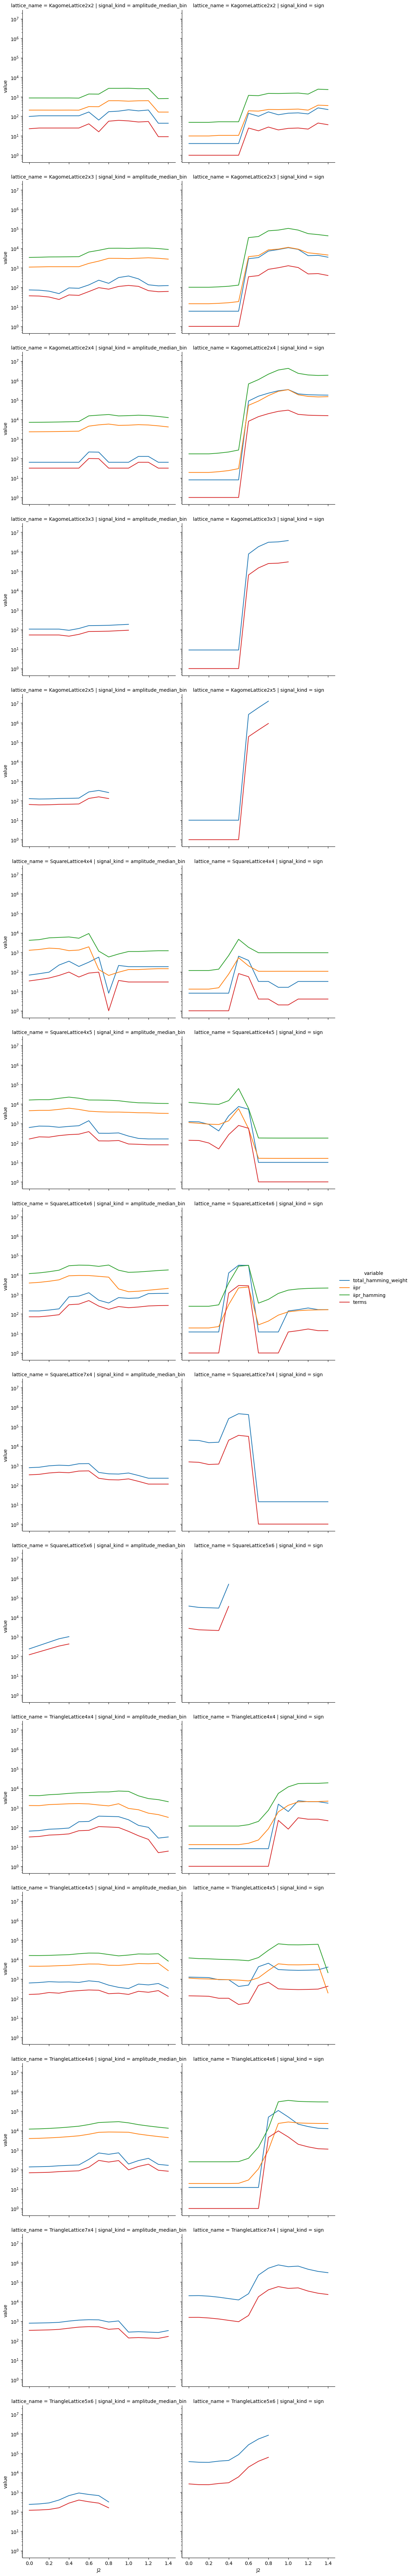

In [11]:
sns.relplot(
    series_df.reset_index()
    .assign(
        iipr_hamming=lambda df: 1 / df["ipr_hamming"],
        iipr=lambda df: 1 / df["ipr"],
    )
    .melt(
        id_vars=["lattice_name", "J2", "signal_kind"],
        value_vars=["total_hamming_weight", "iipr", "iipr_hamming", "terms"],
    )
    .dropna(),
    x="J2",
    y="value",
    hue="variable",
    row="lattice_name",
    col="signal_kind",
    kind="line",
).set(yscale="log")


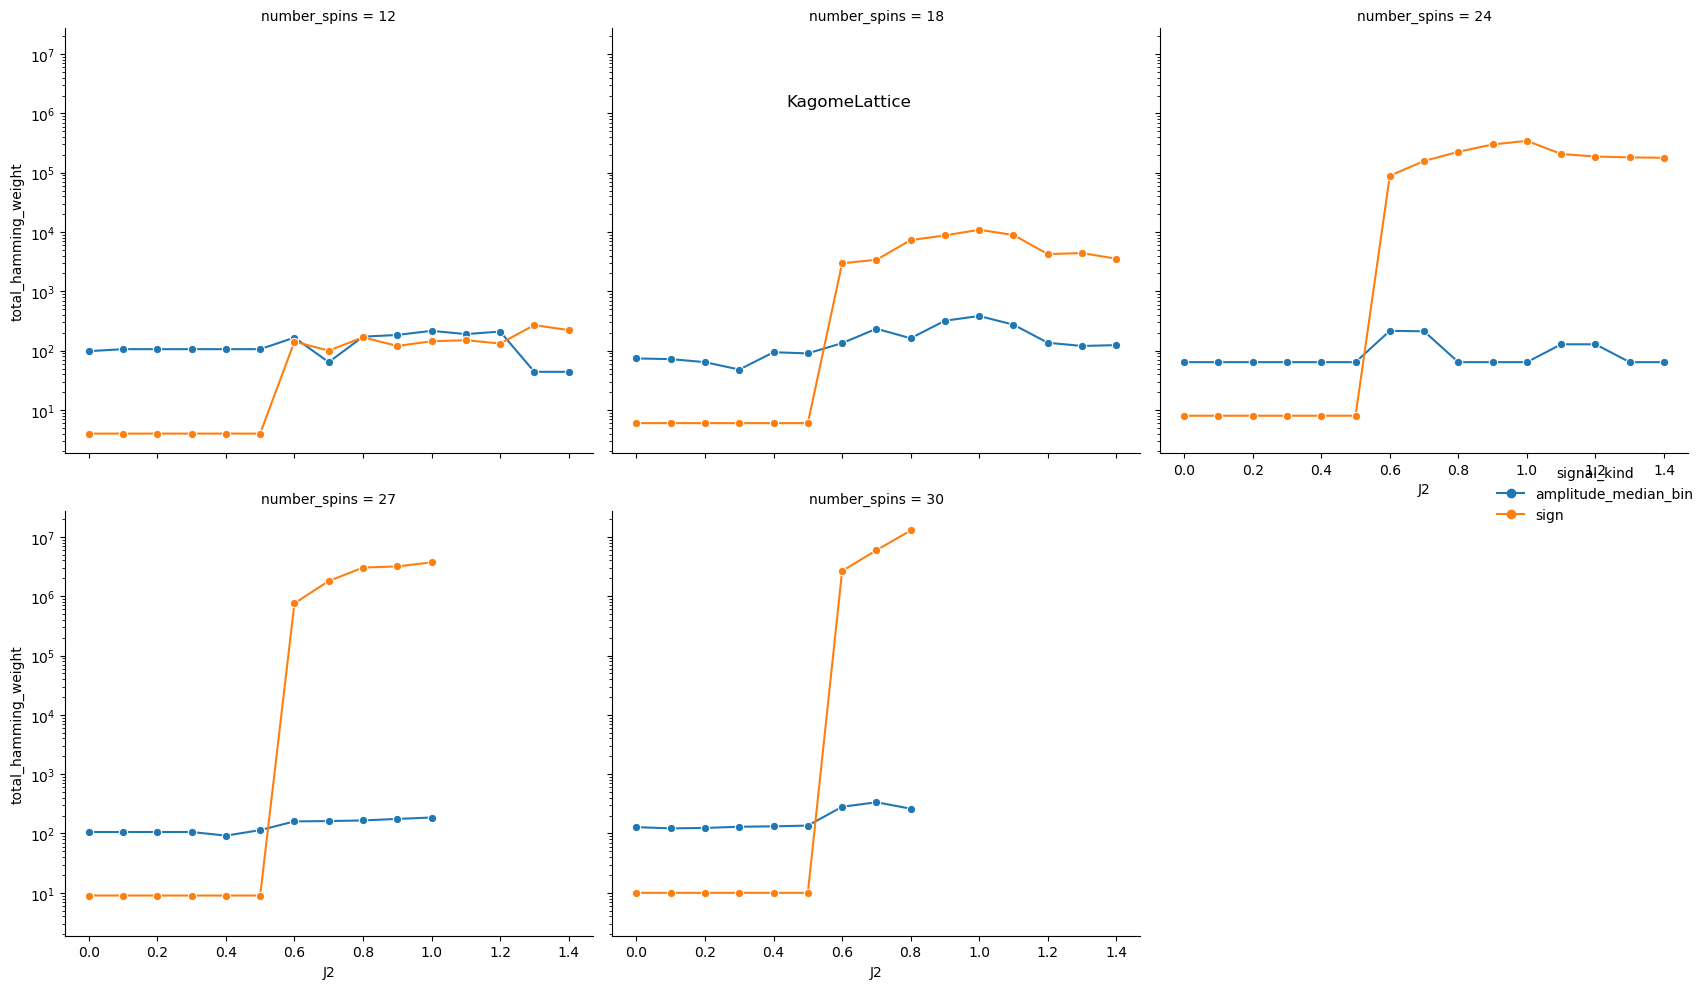

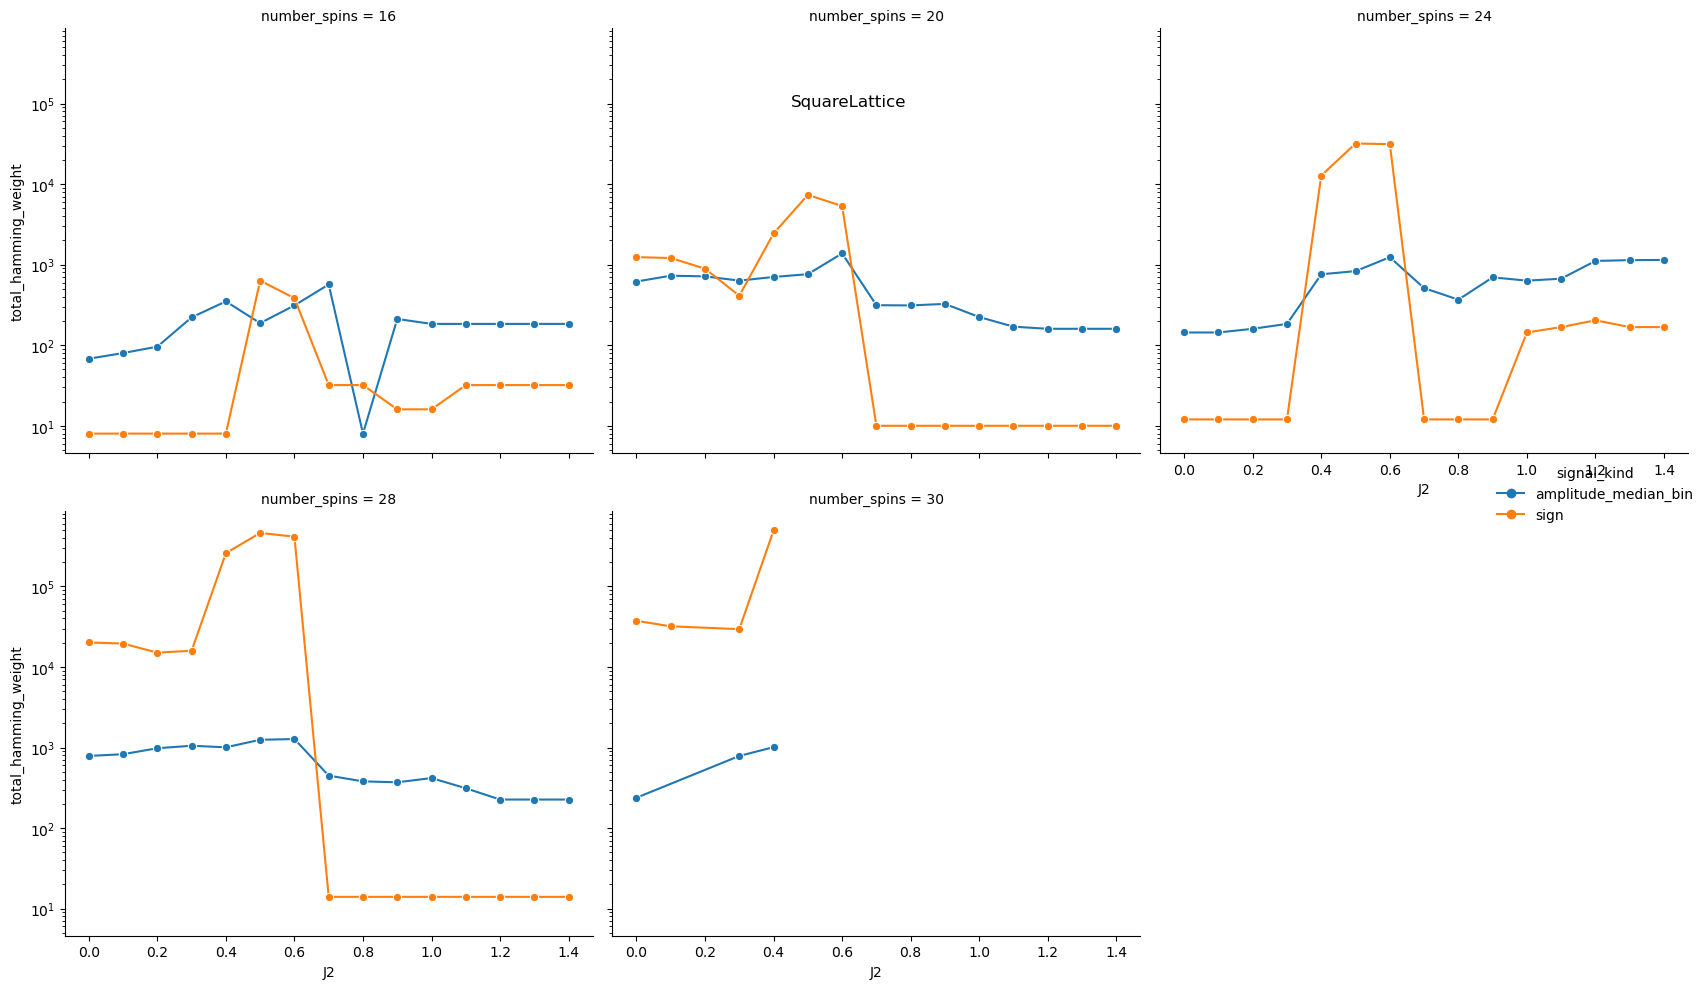

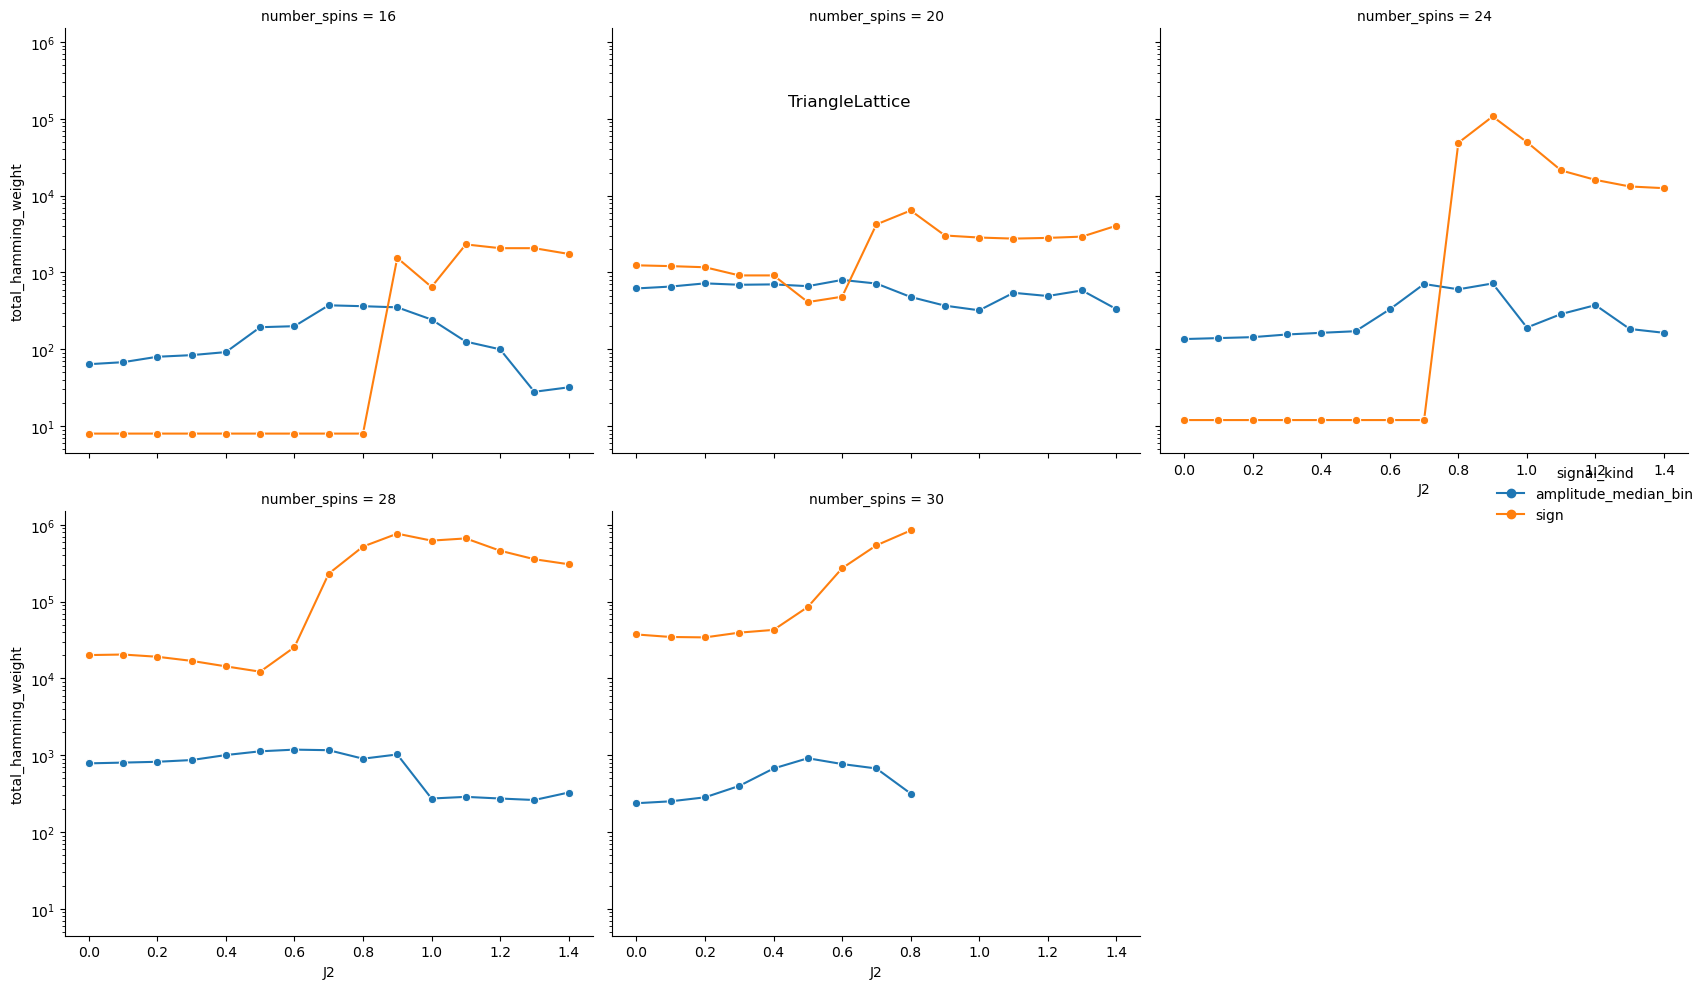

In [10]:
for lattice_type, df in series_df.reset_index().groupby("lattice_type"):

    g = sns.relplot(
        df,  # .query("number_spins < 28"),
        x="J2",
        y="total_hamming_weight",
        hue="signal_kind",
        col="number_spins",
        col_wrap=3,
        kind="line",
        # markers=True,
        style="signal_kind",
        dashes=False,
        markers=["o", "o"],
        # make y axis independent
        # facet_kws=dict(sharey=False),
    )  # log scale
    g.set(yscale="log")
    g.fig.tight_layout()
    g.fig.suptitle(f"{lattice_type}", y=0.9)


In [18]:
(
    series_df.query("number_spins == 24")
    .reset_index()
    .groupby(["lattice_name", "signal_kind"])[["terms", "ipr_hamming"]]
    .max()
)


terms  ipr_hamming
lattice_name       signal_kind                             
KagomeLattice2x4   amplitude_median_bin    100     0.000428
                   sign                  30205     0.052010
SquareLattice4x6   amplitude_median_bin    489     0.000718
                   sign                   2906     0.052010
TriangleLattice4x6 amplitude_median_bin    294     0.000257
                   sign                   9614     0.052010

[None]

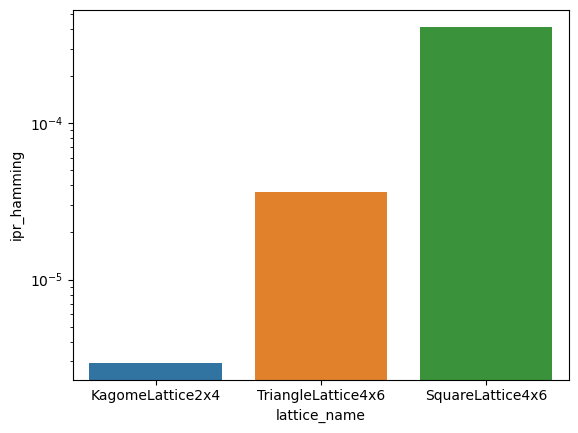

In [20]:
sns.barplot(
    series_df.query("number_spins == 24 and signal_kind == 'sign'")
    .reset_index()
    .groupby(["lattice_name", "signal_kind"])[["terms", "ipr_hamming"]]
    .min()
    .sort_values("ipr_hamming")
    .reset_index(),
    x="lattice_name",
    y="ipr_hamming",
).set(yscale="log")


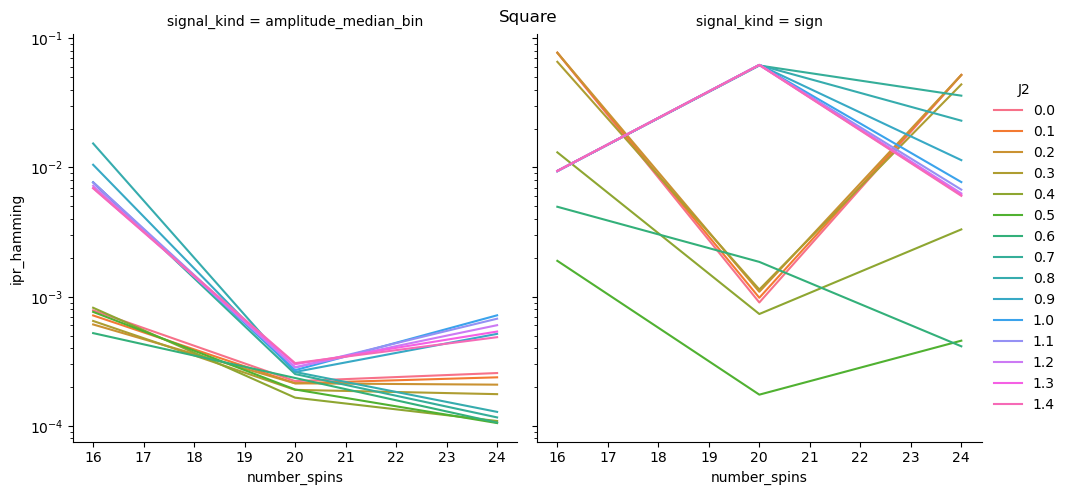

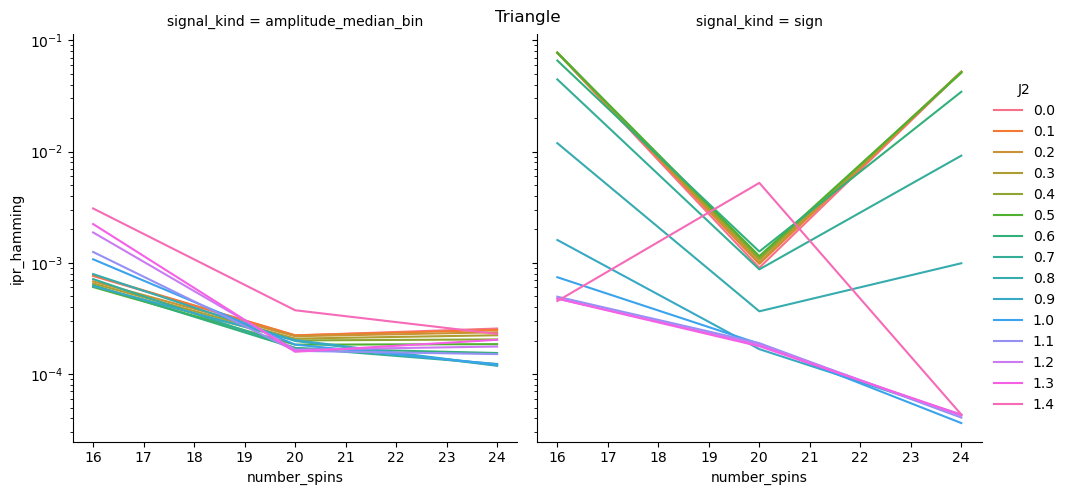

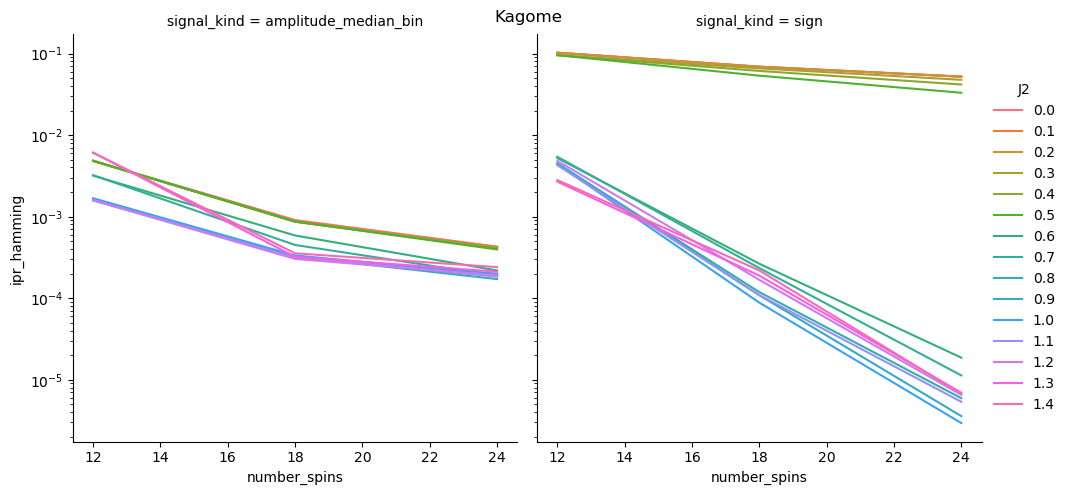

In [21]:
for lat in ["Square", "Triangle", "Kagome"]:

    plot = sns.relplot(
        series_df.reset_index()
        .query("lattice_name.str.startswith(@lat)")
        .assign(J2=lambda df: df["J2"].astype(str)),
        x="number_spins",
        y="ipr_hamming",
        col="signal_kind",
        hue="J2",
        kind="line",
        markers=True,
    ).set(yscale="log")
    plot.fig.suptitle(lat)


In [11]:
def plot_subsets(subsets, titles, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset, title in zip(axes[0], subsets, titles):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
        ax.set_title(title)
    return fig


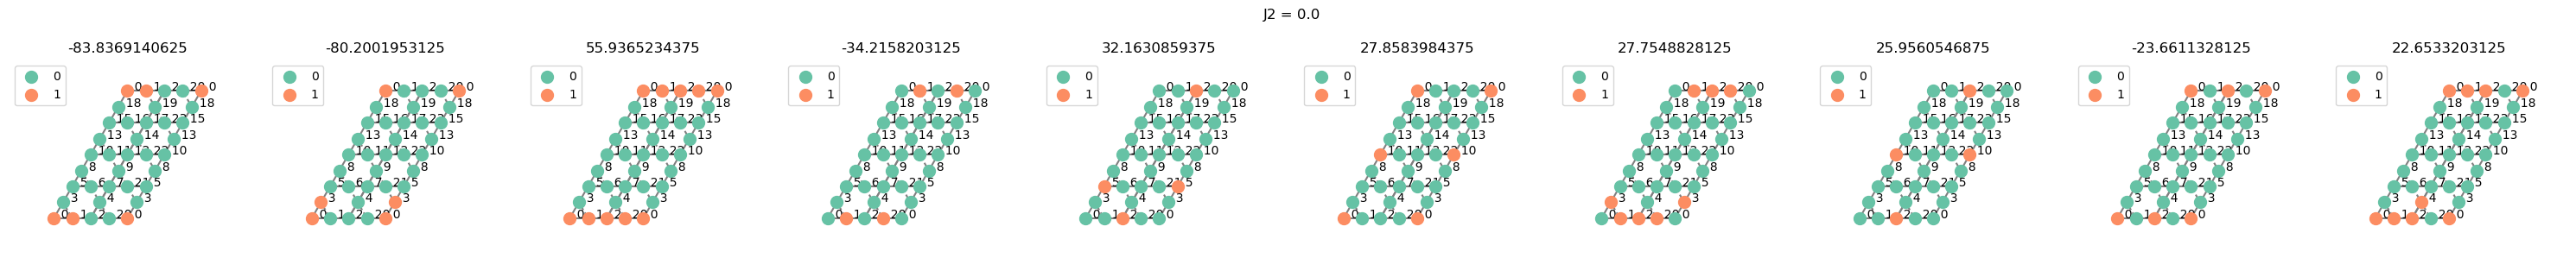

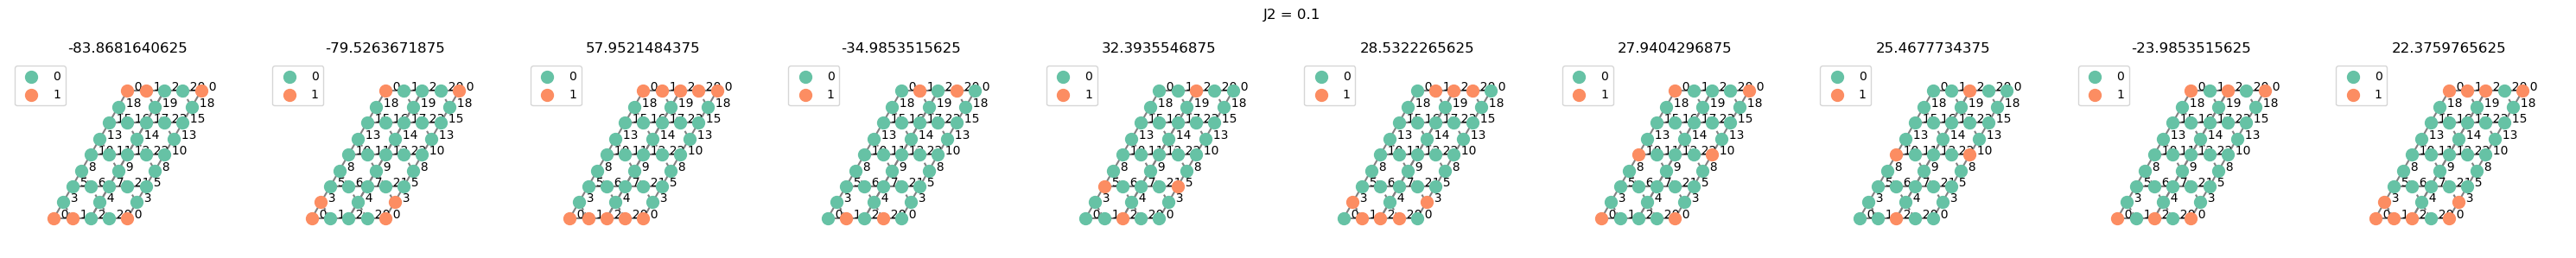

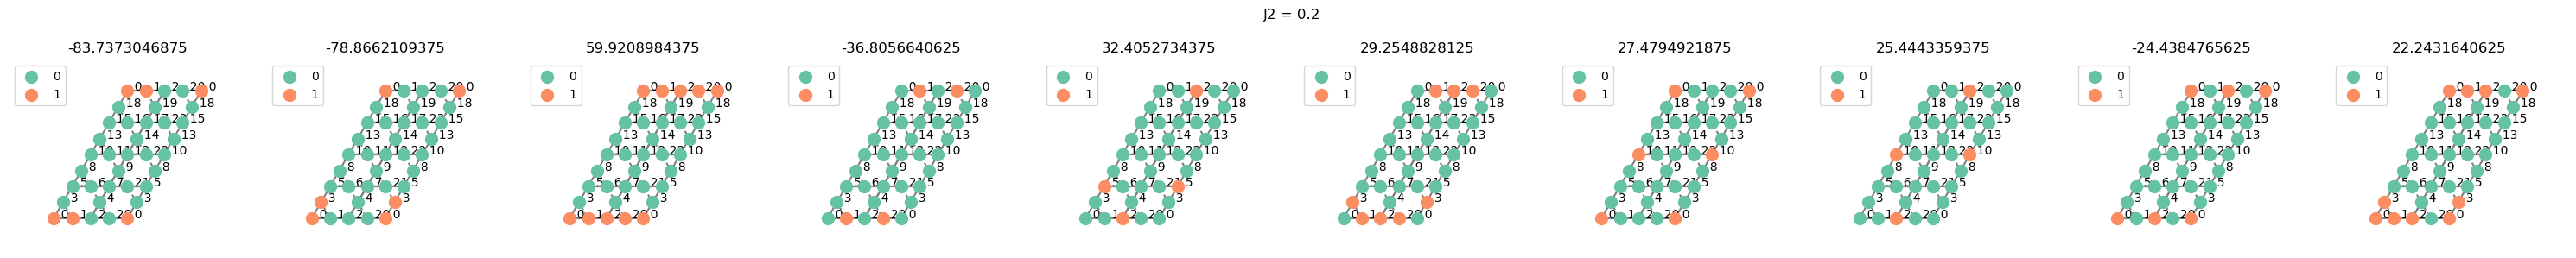

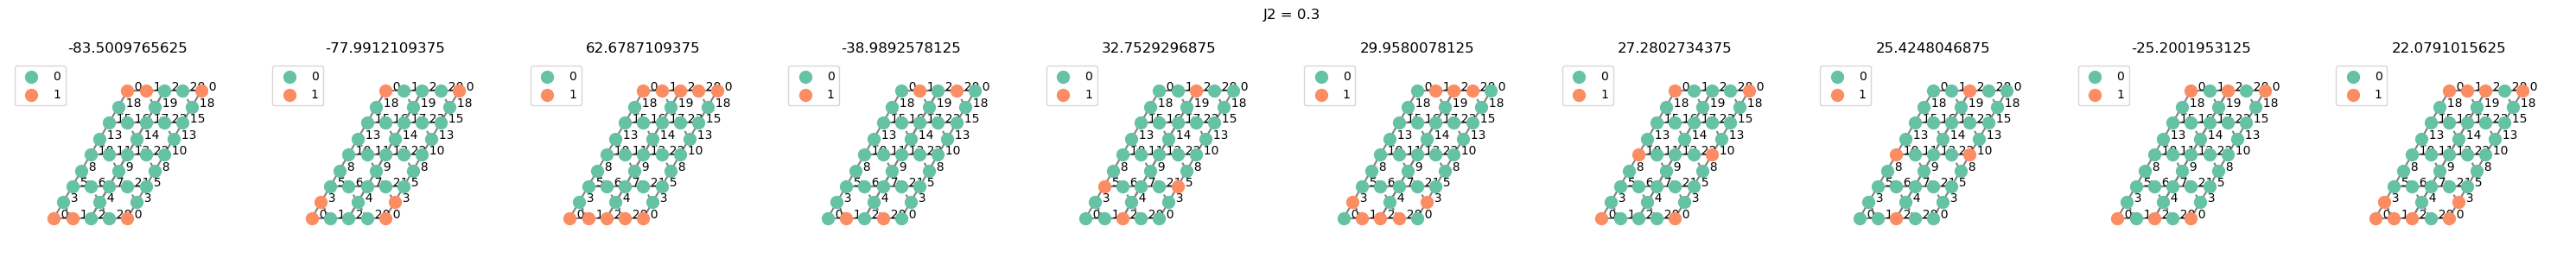

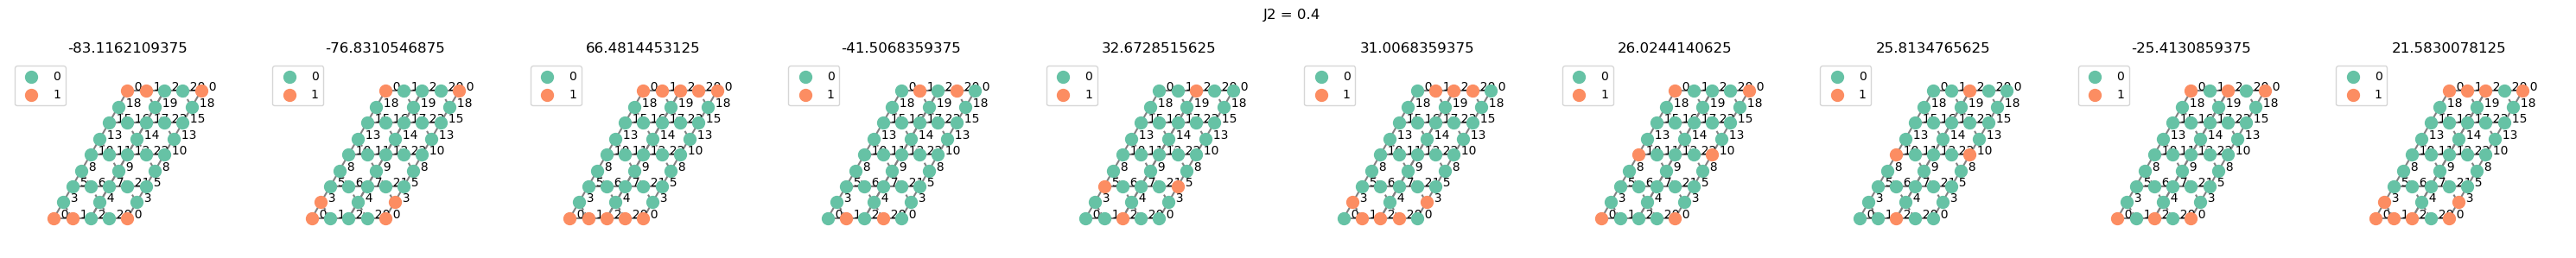

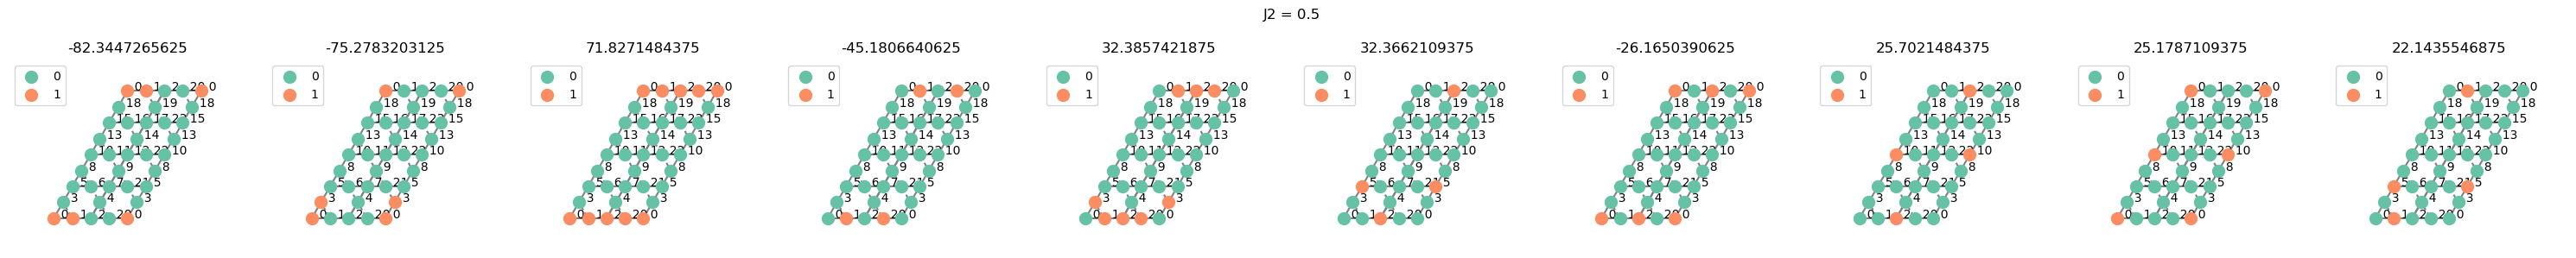

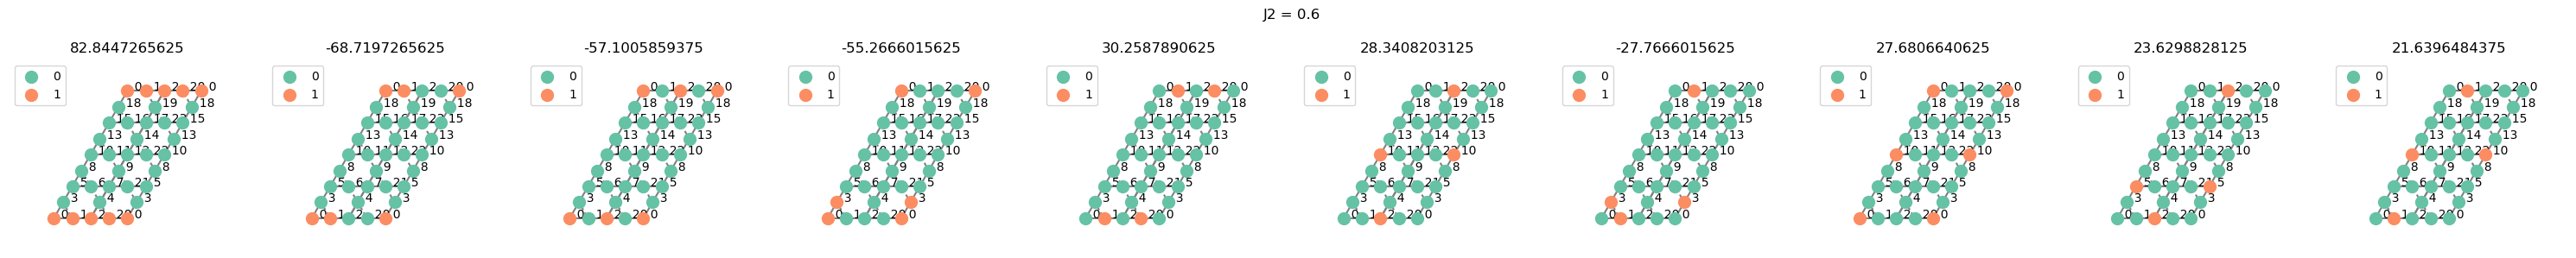

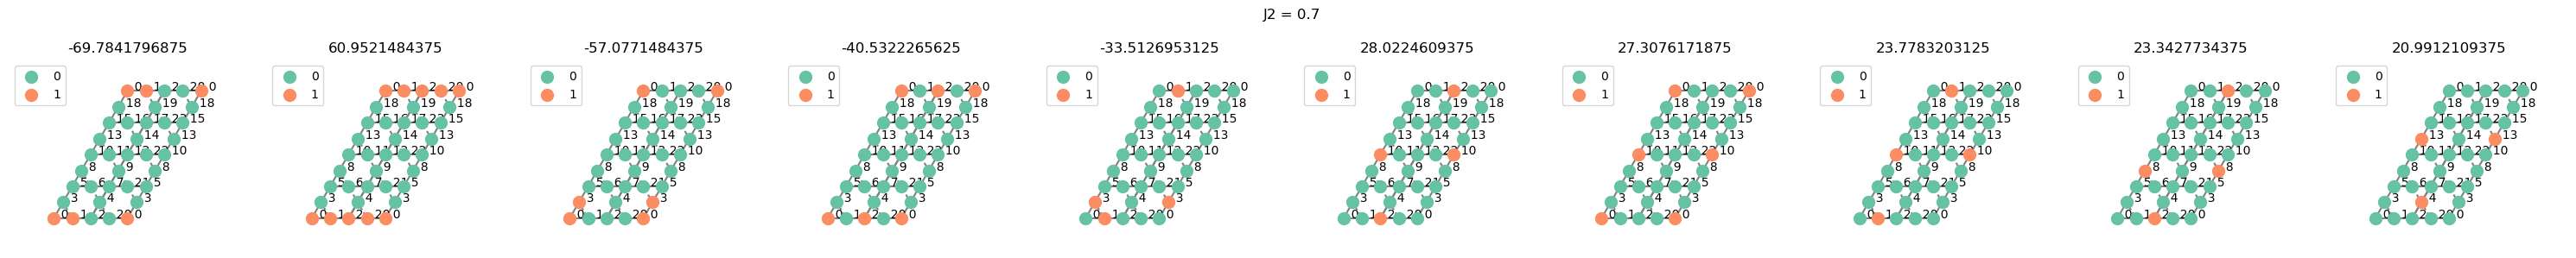

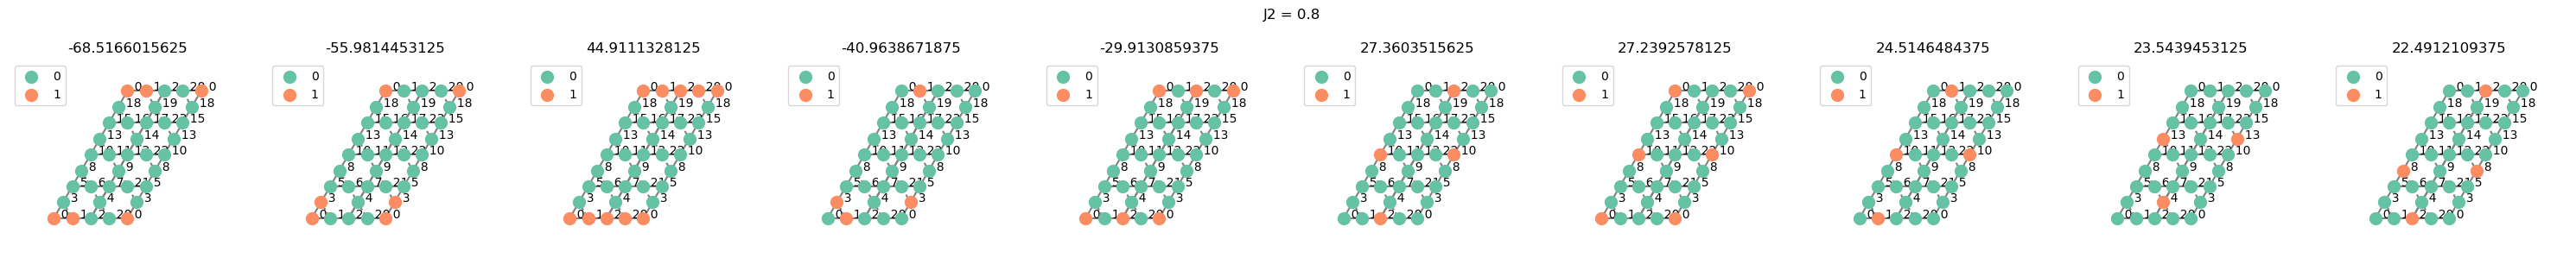

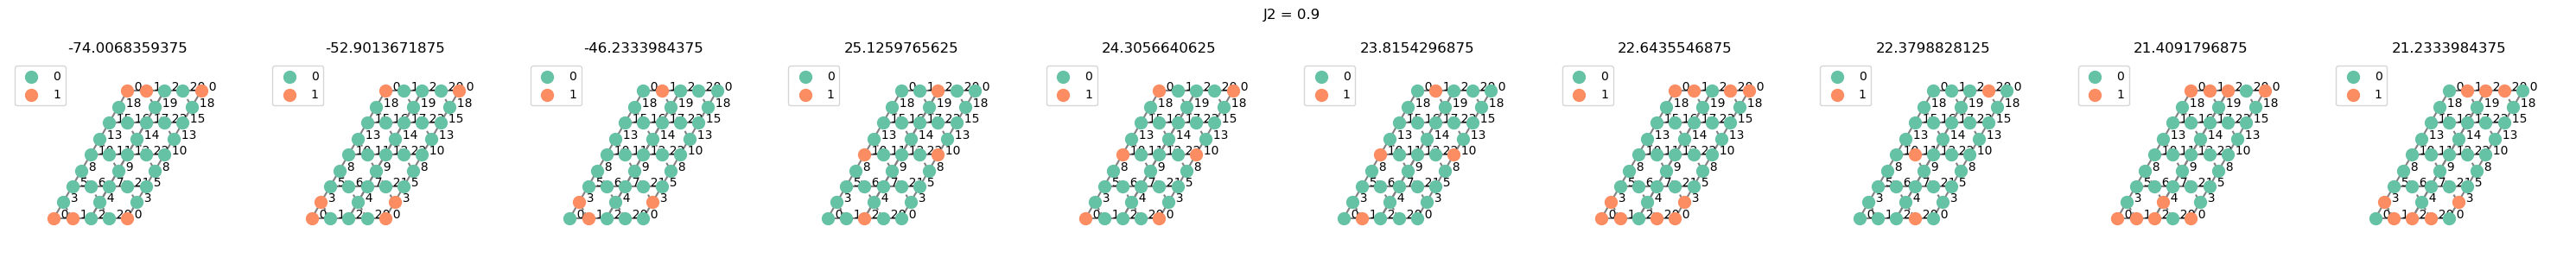

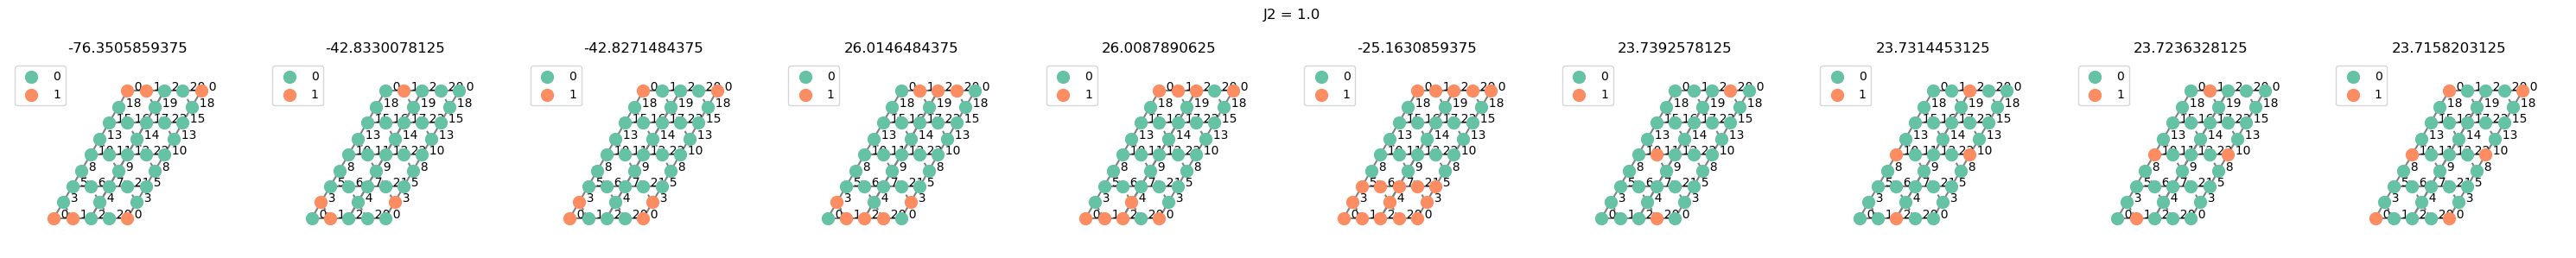

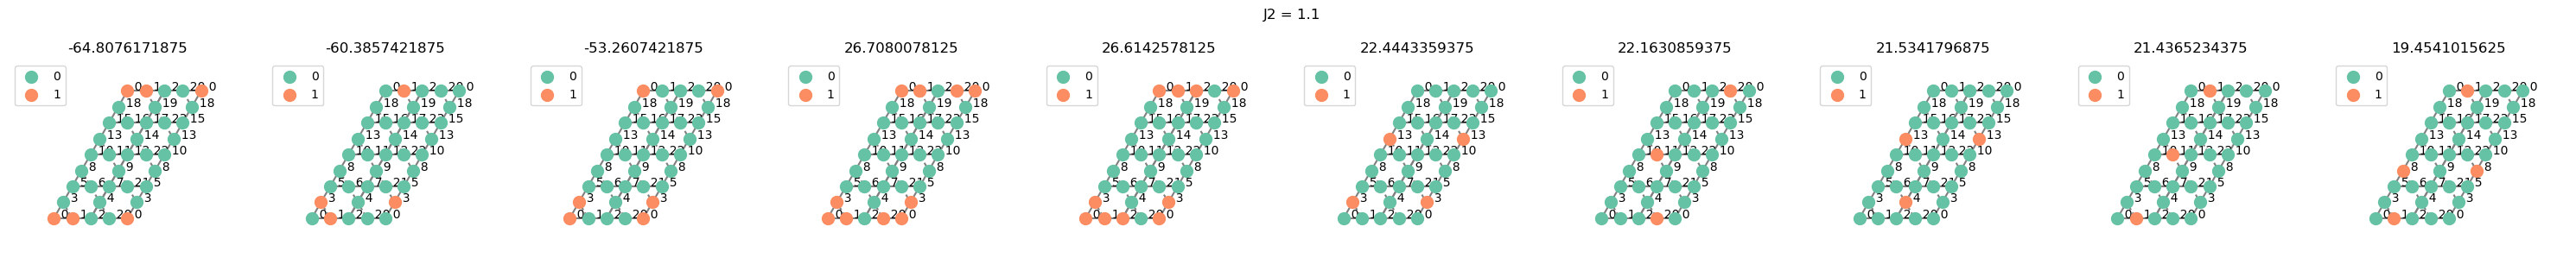

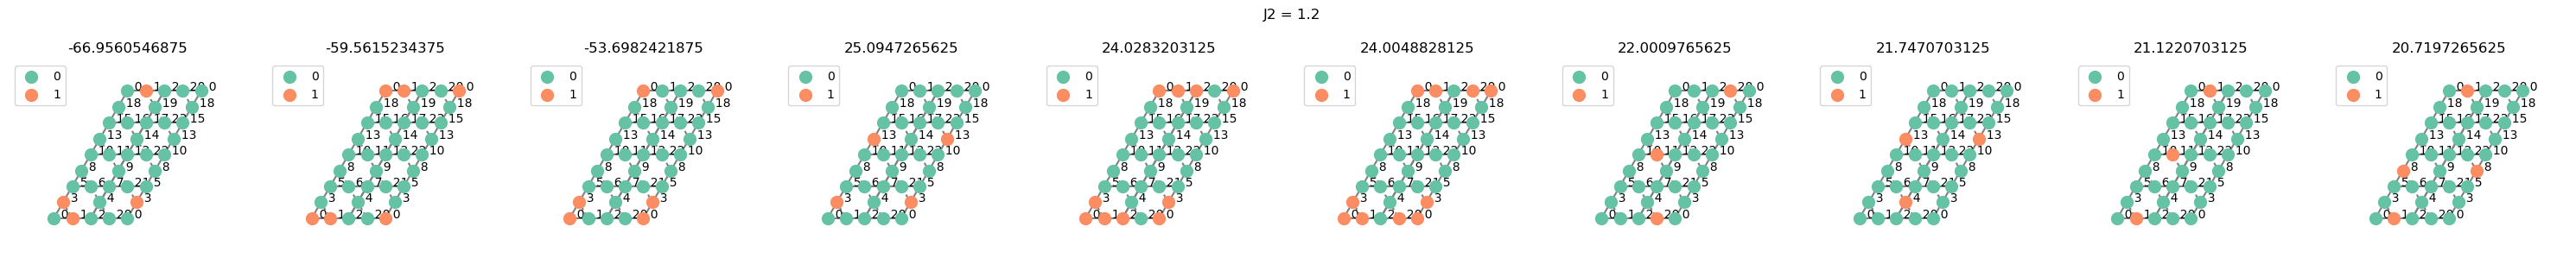

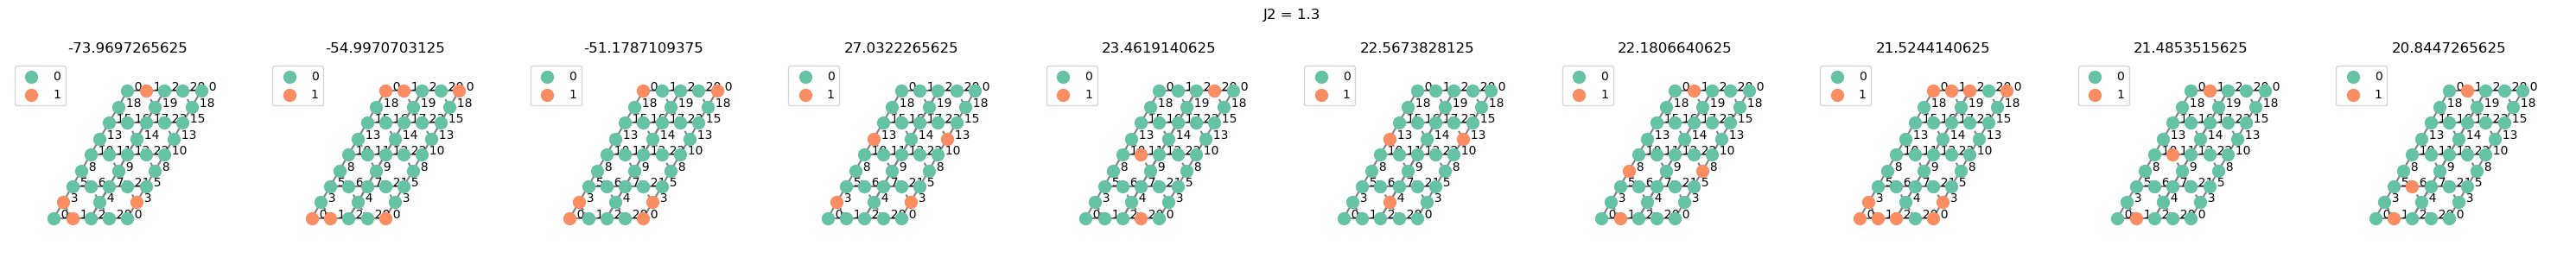

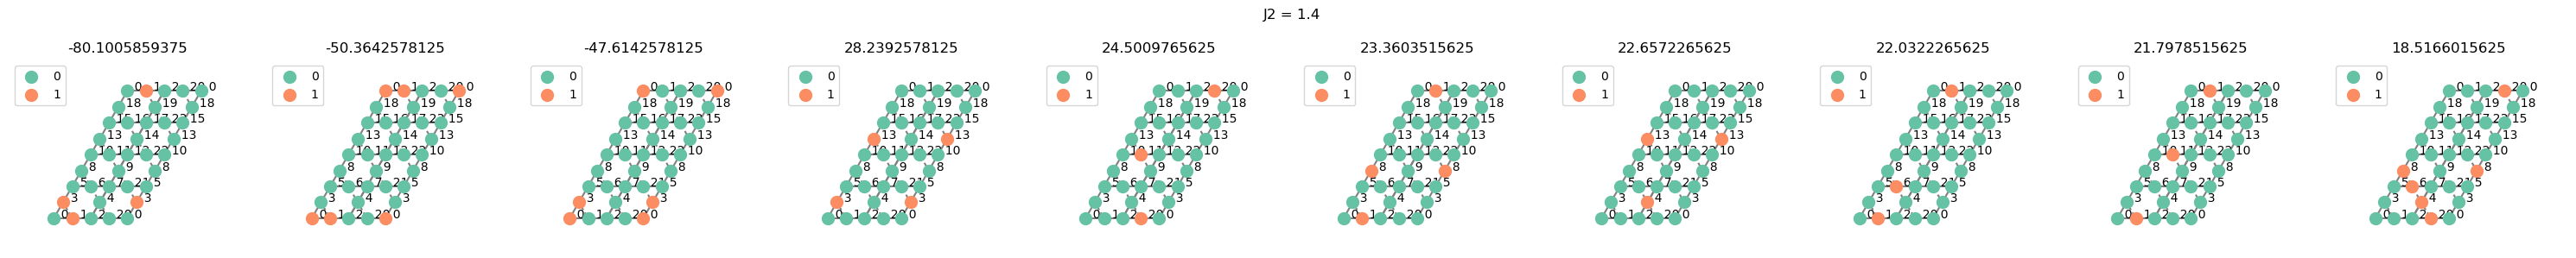

In [12]:
lattice_name = "KagomeLattice2x4"
signal = "amplitude_median_bin"

for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = plot_subsets(subsets, coeffs, name_to_lat_and_sym[lattice_name][0])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()


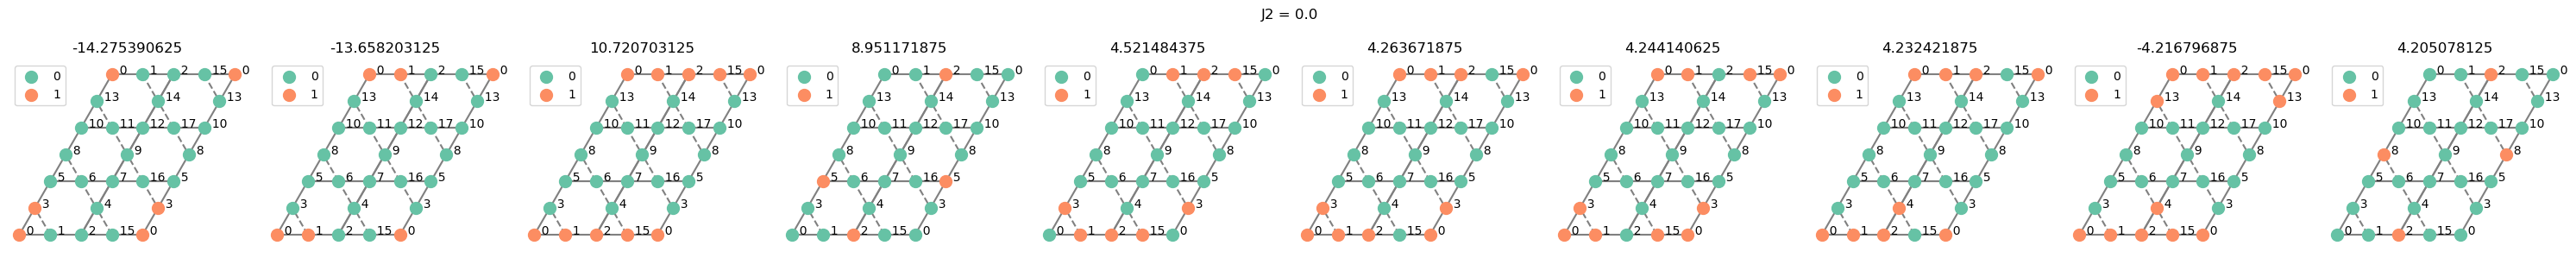

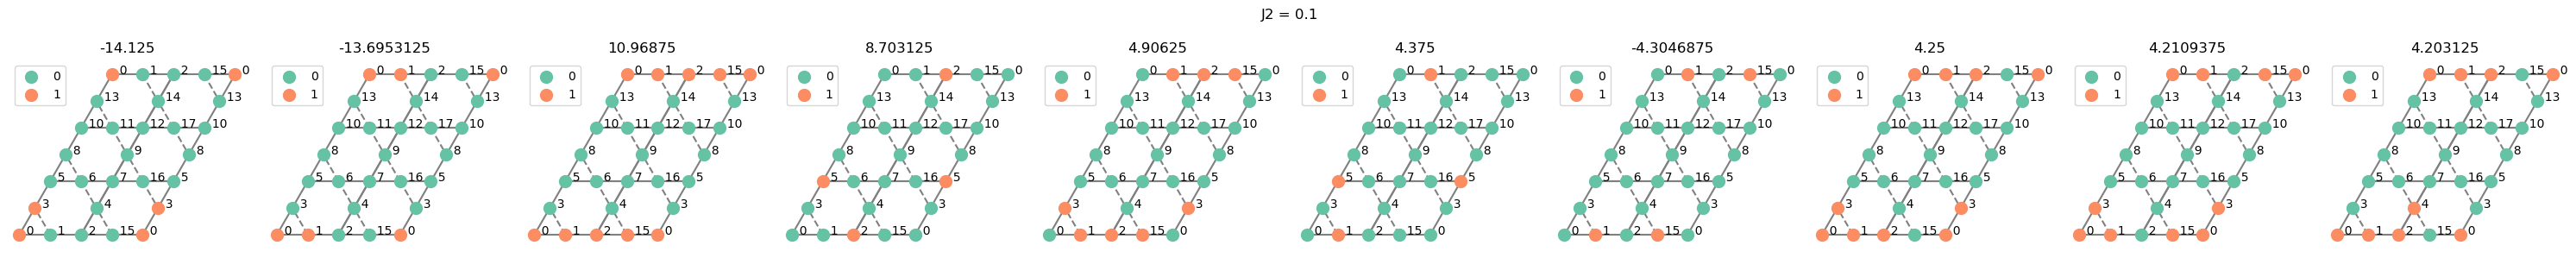

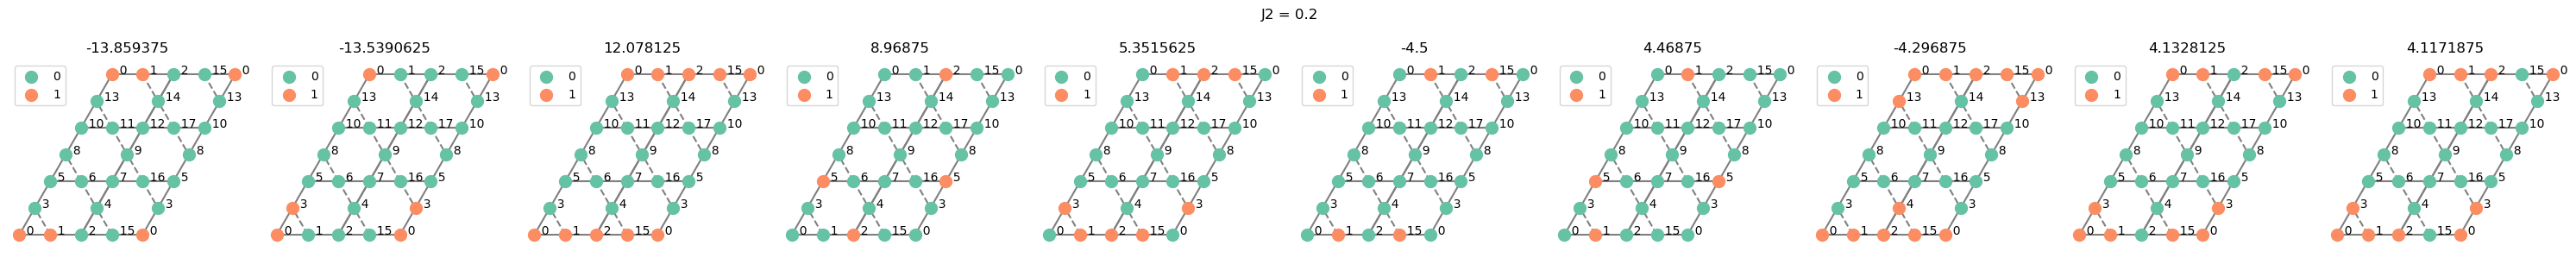

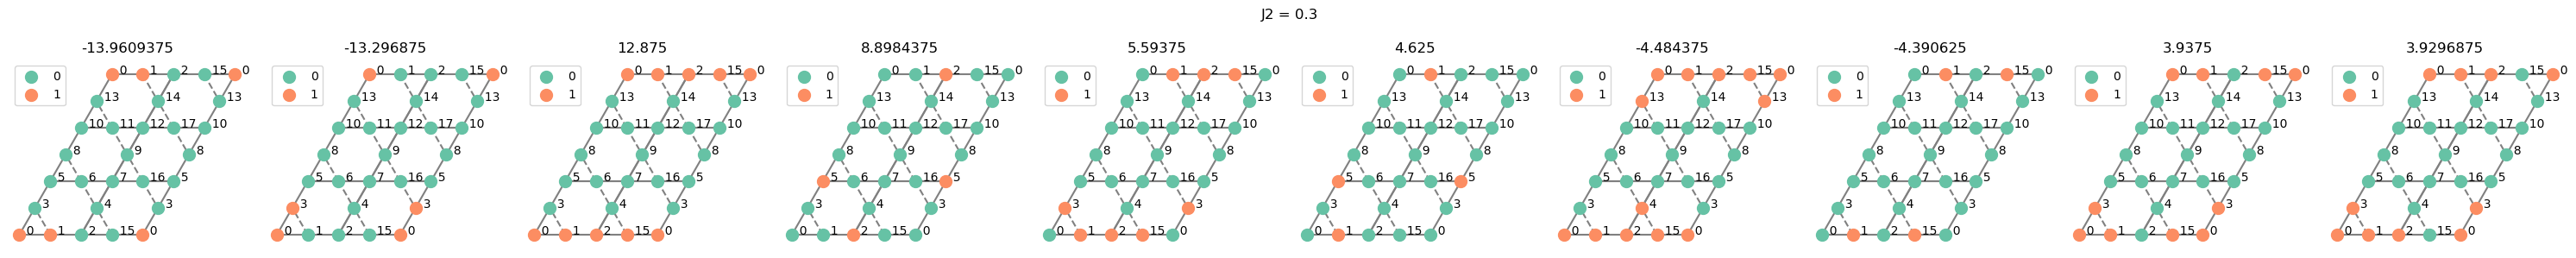

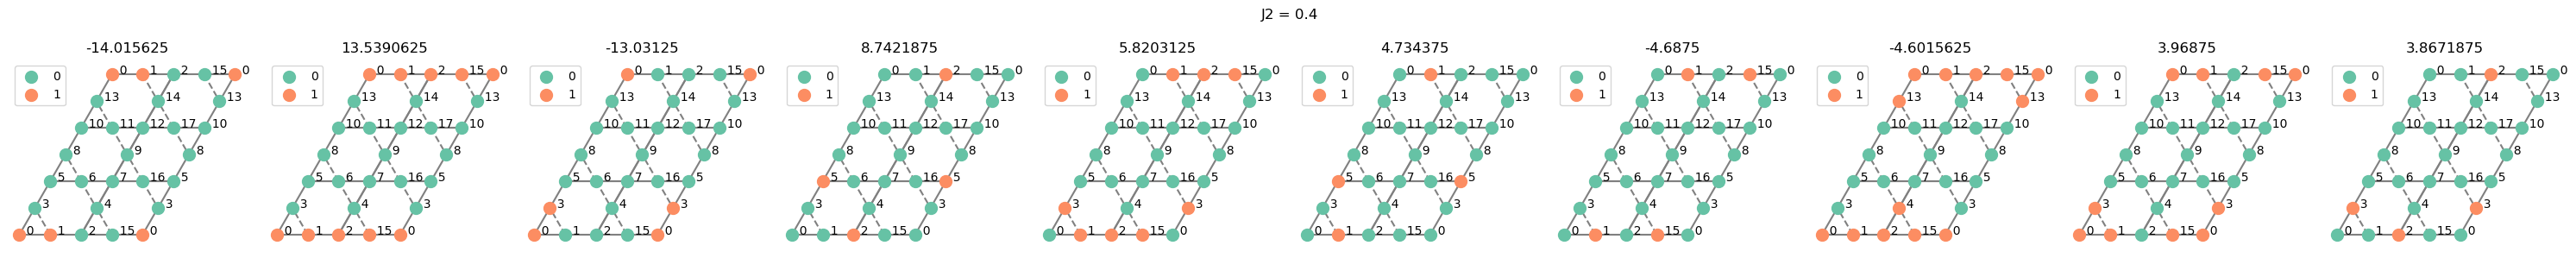

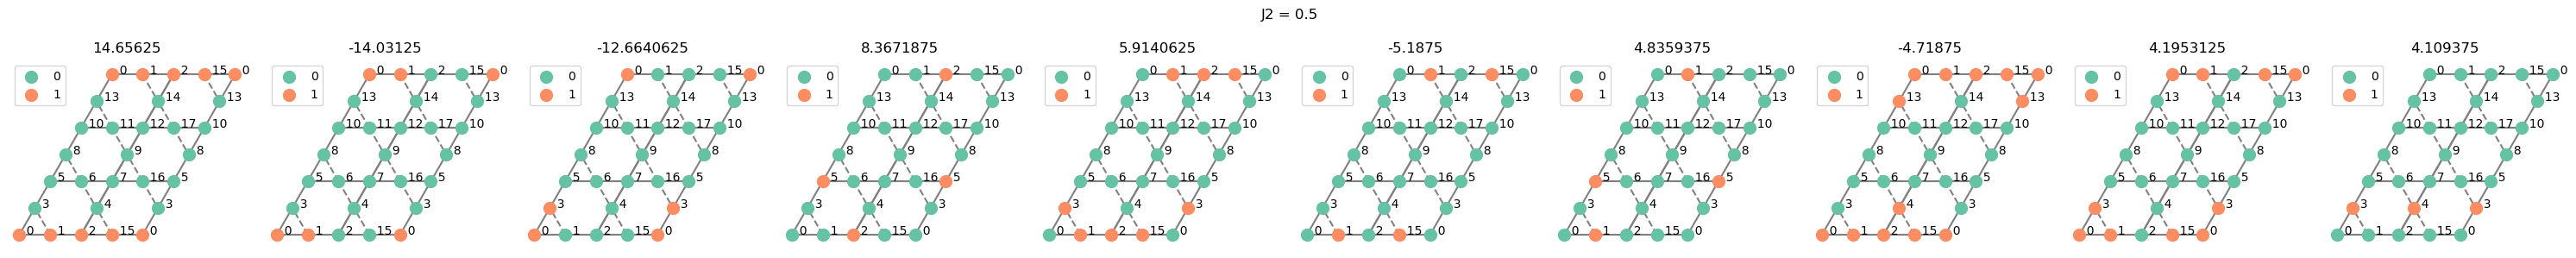

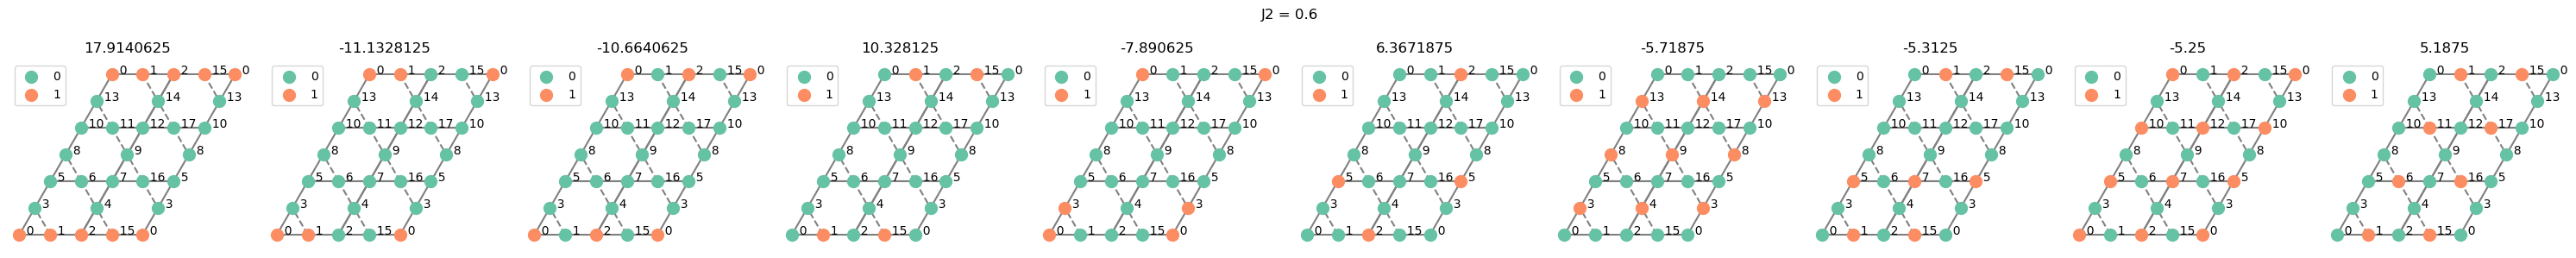

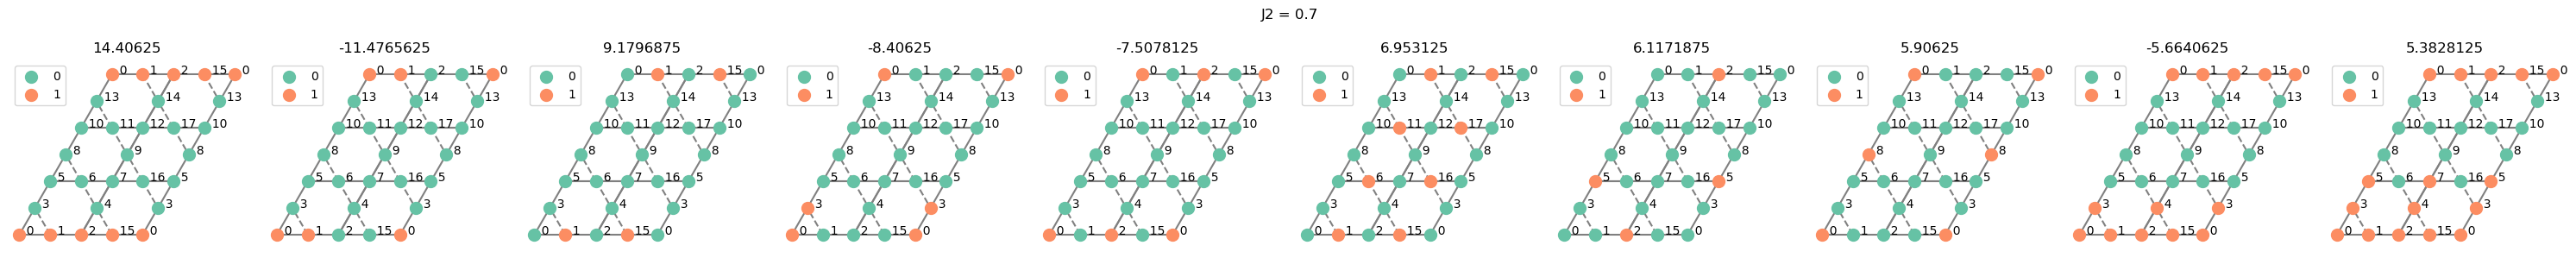

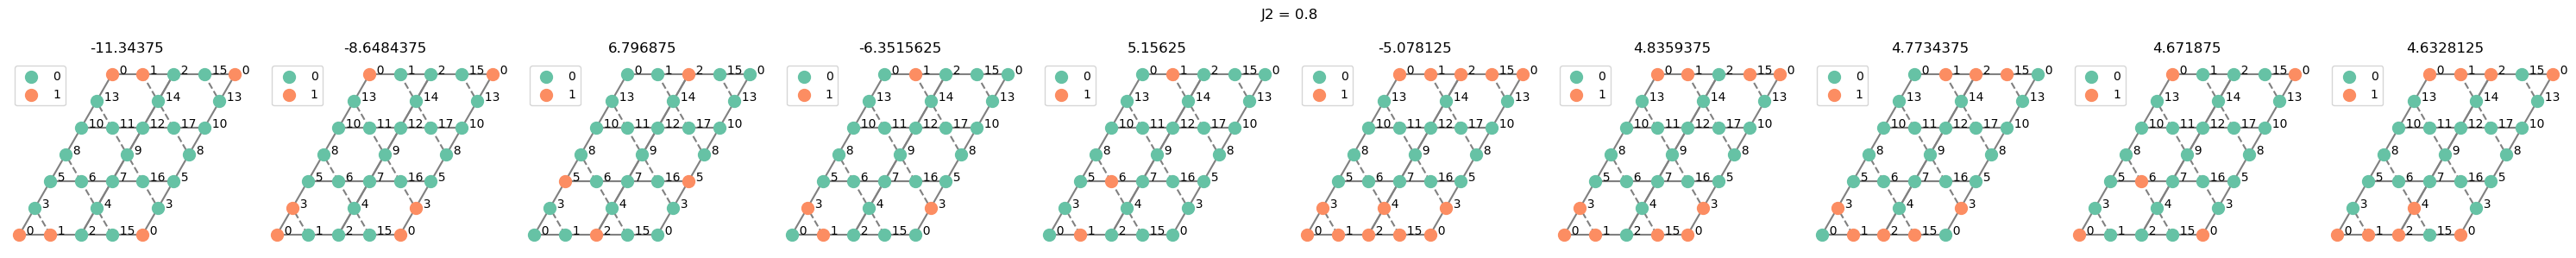

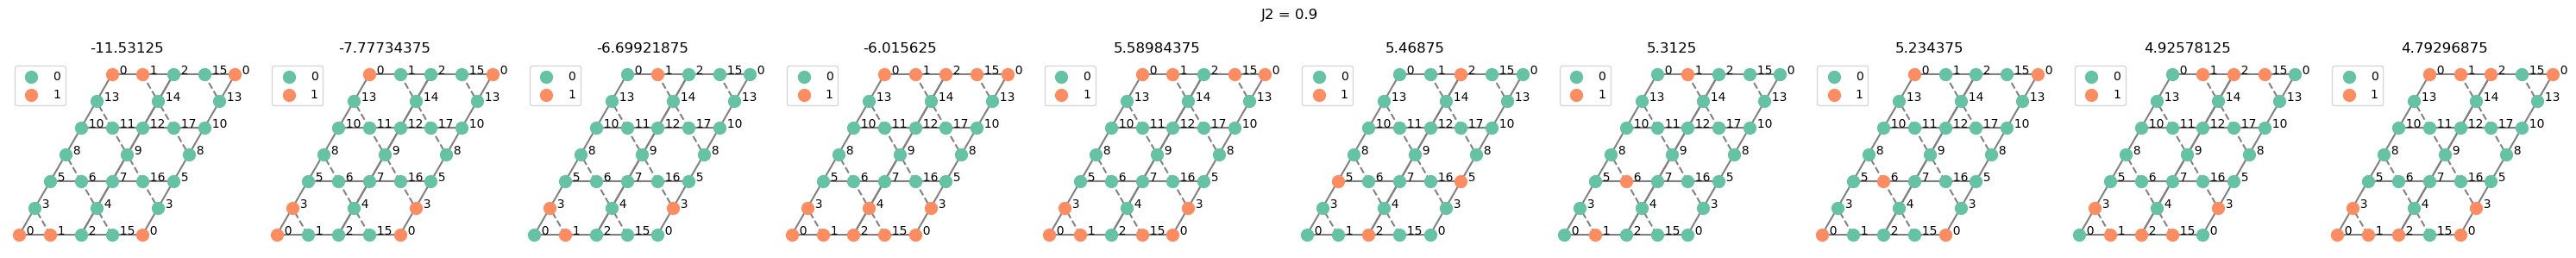

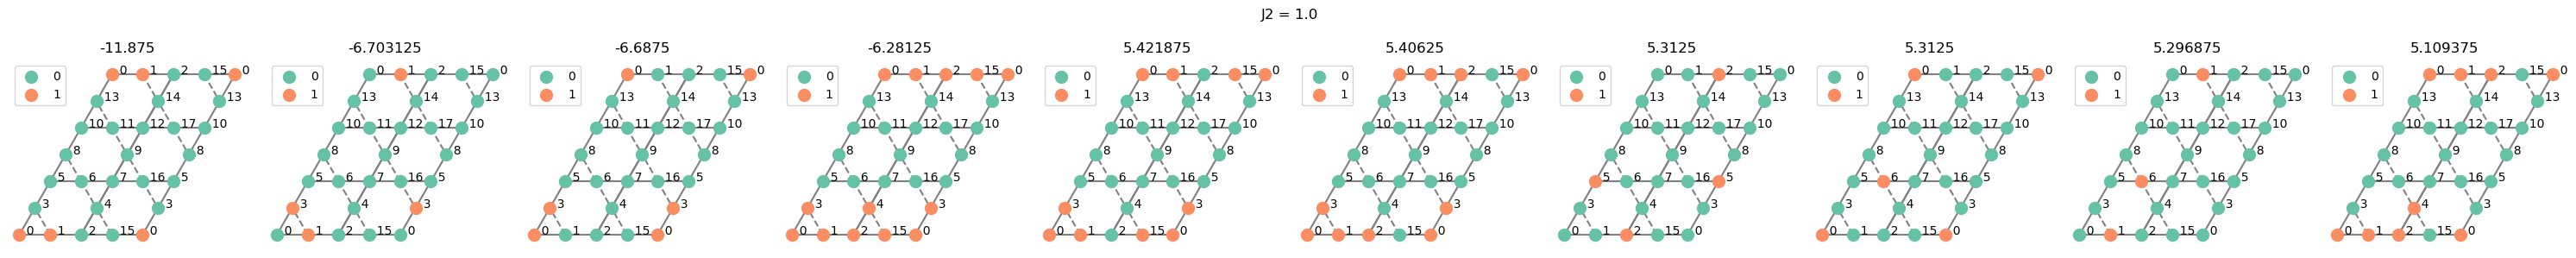

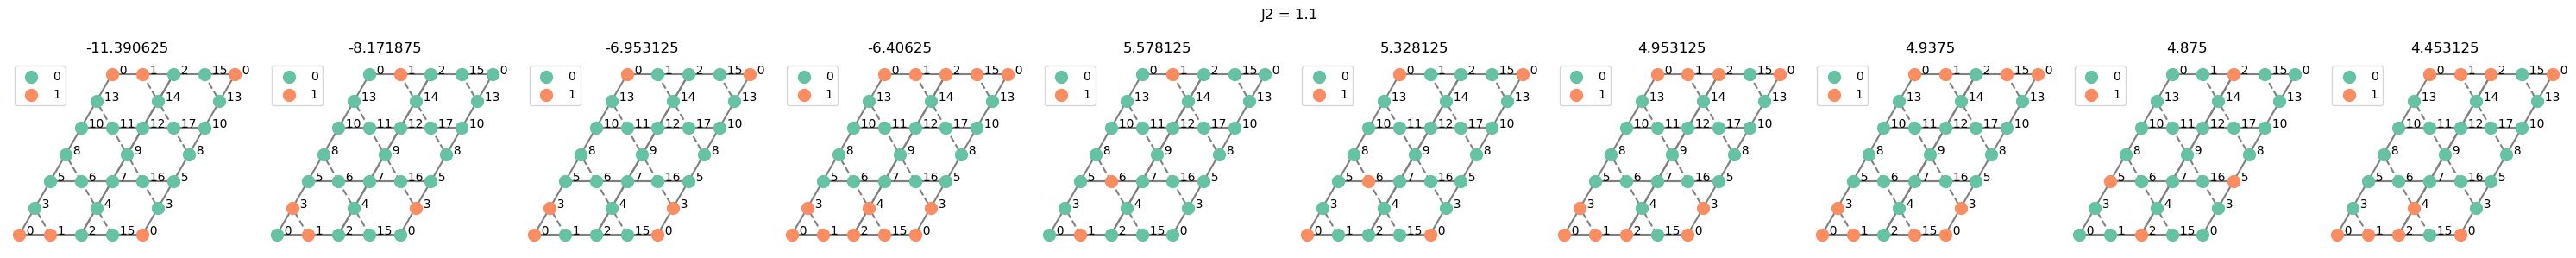

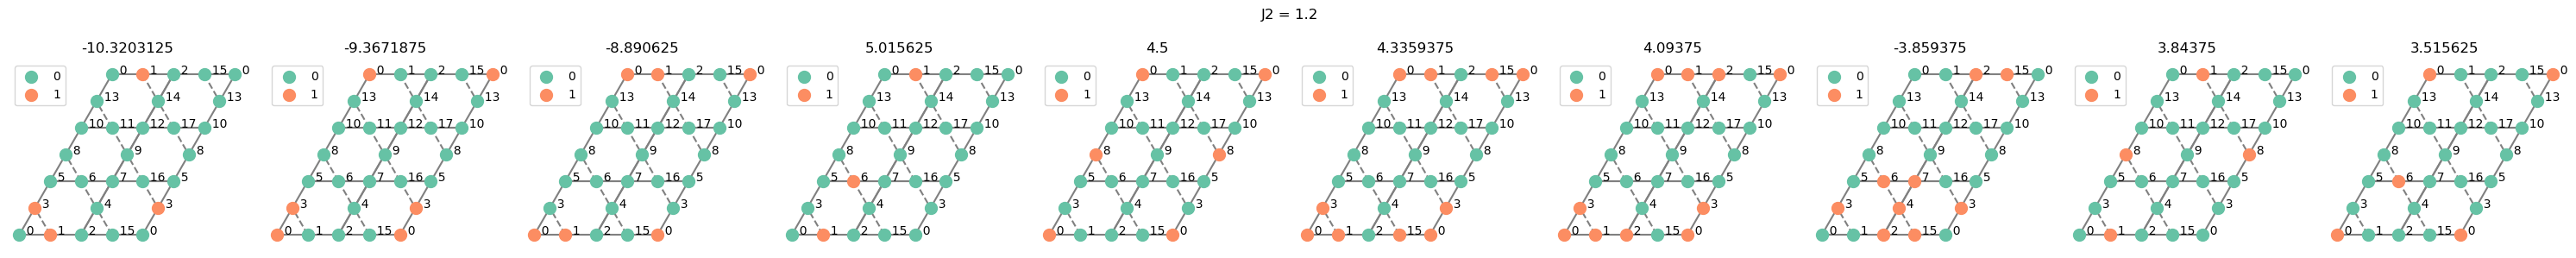

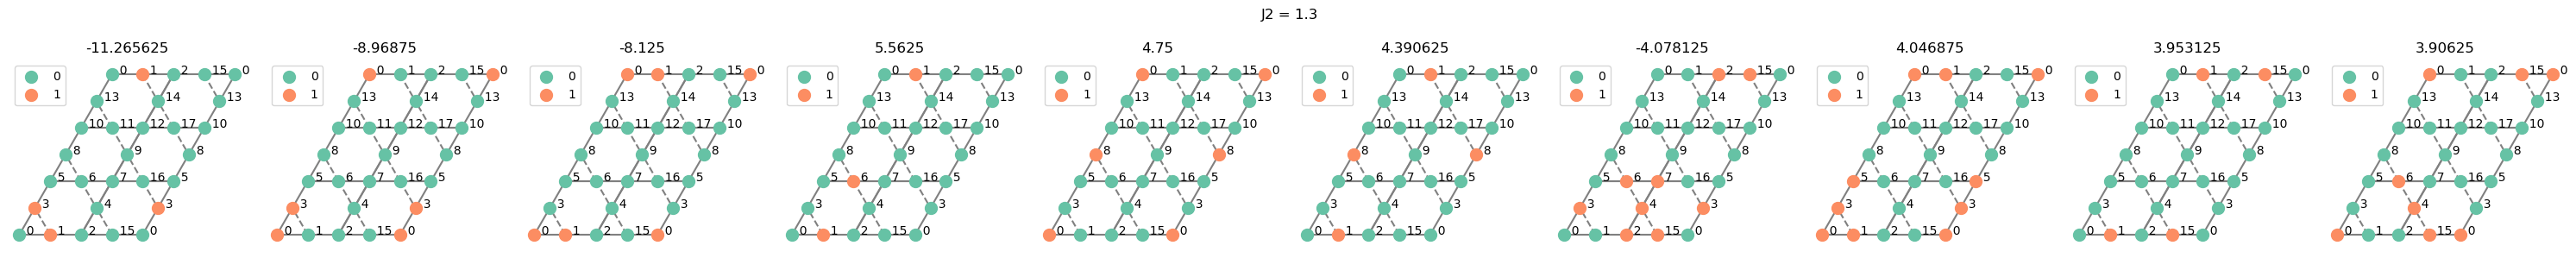

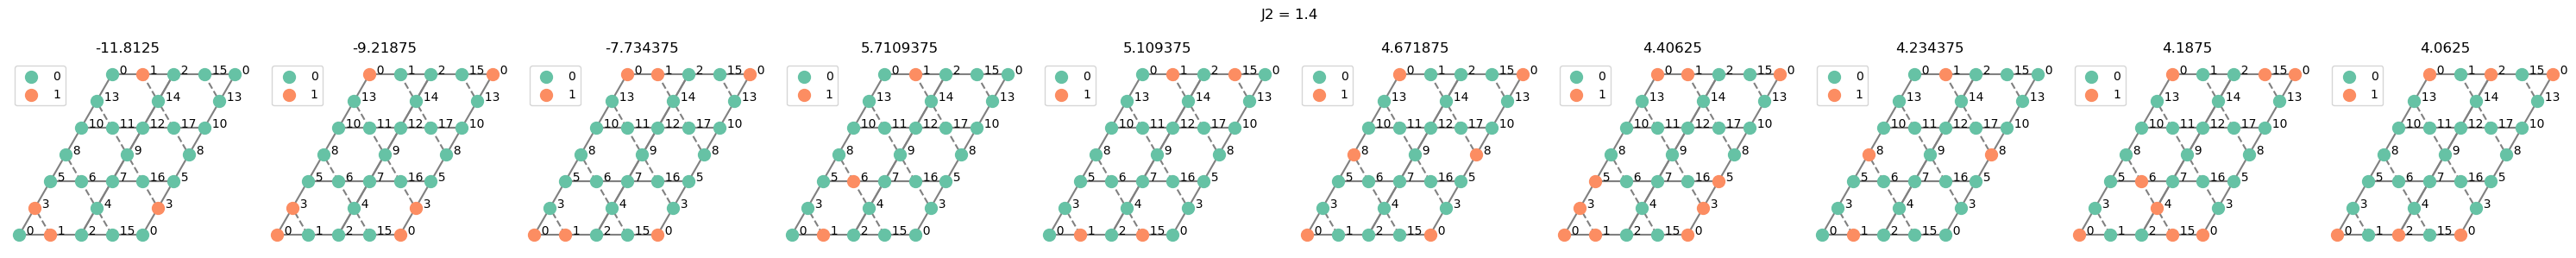

In [13]:
lattice_name = "KagomeLattice2x3"
signal = "amplitude_median_bin"

for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = plot_subsets(subsets, coeffs, name_to_lat_and_sym[lattice_name][0])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()


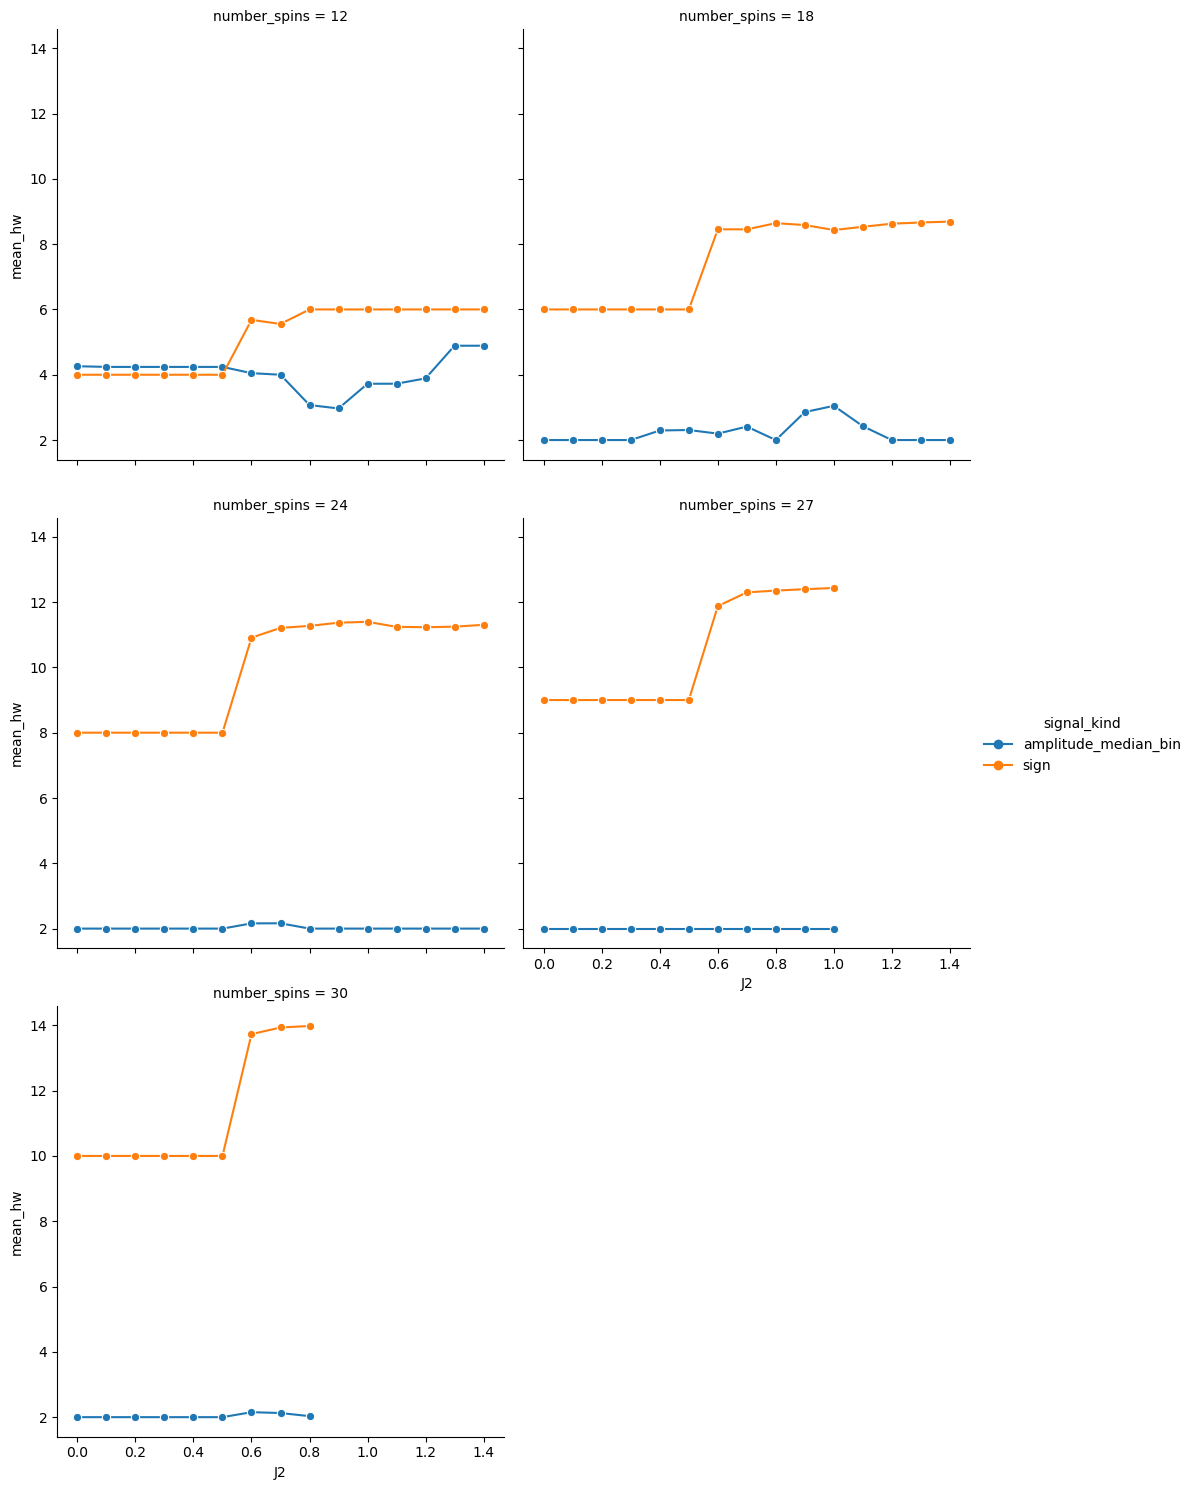

In [17]:
sns.relplot(
    series_df.query("lattice_name.str.startswith('Kagome')"),
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    col_wrap=2,
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


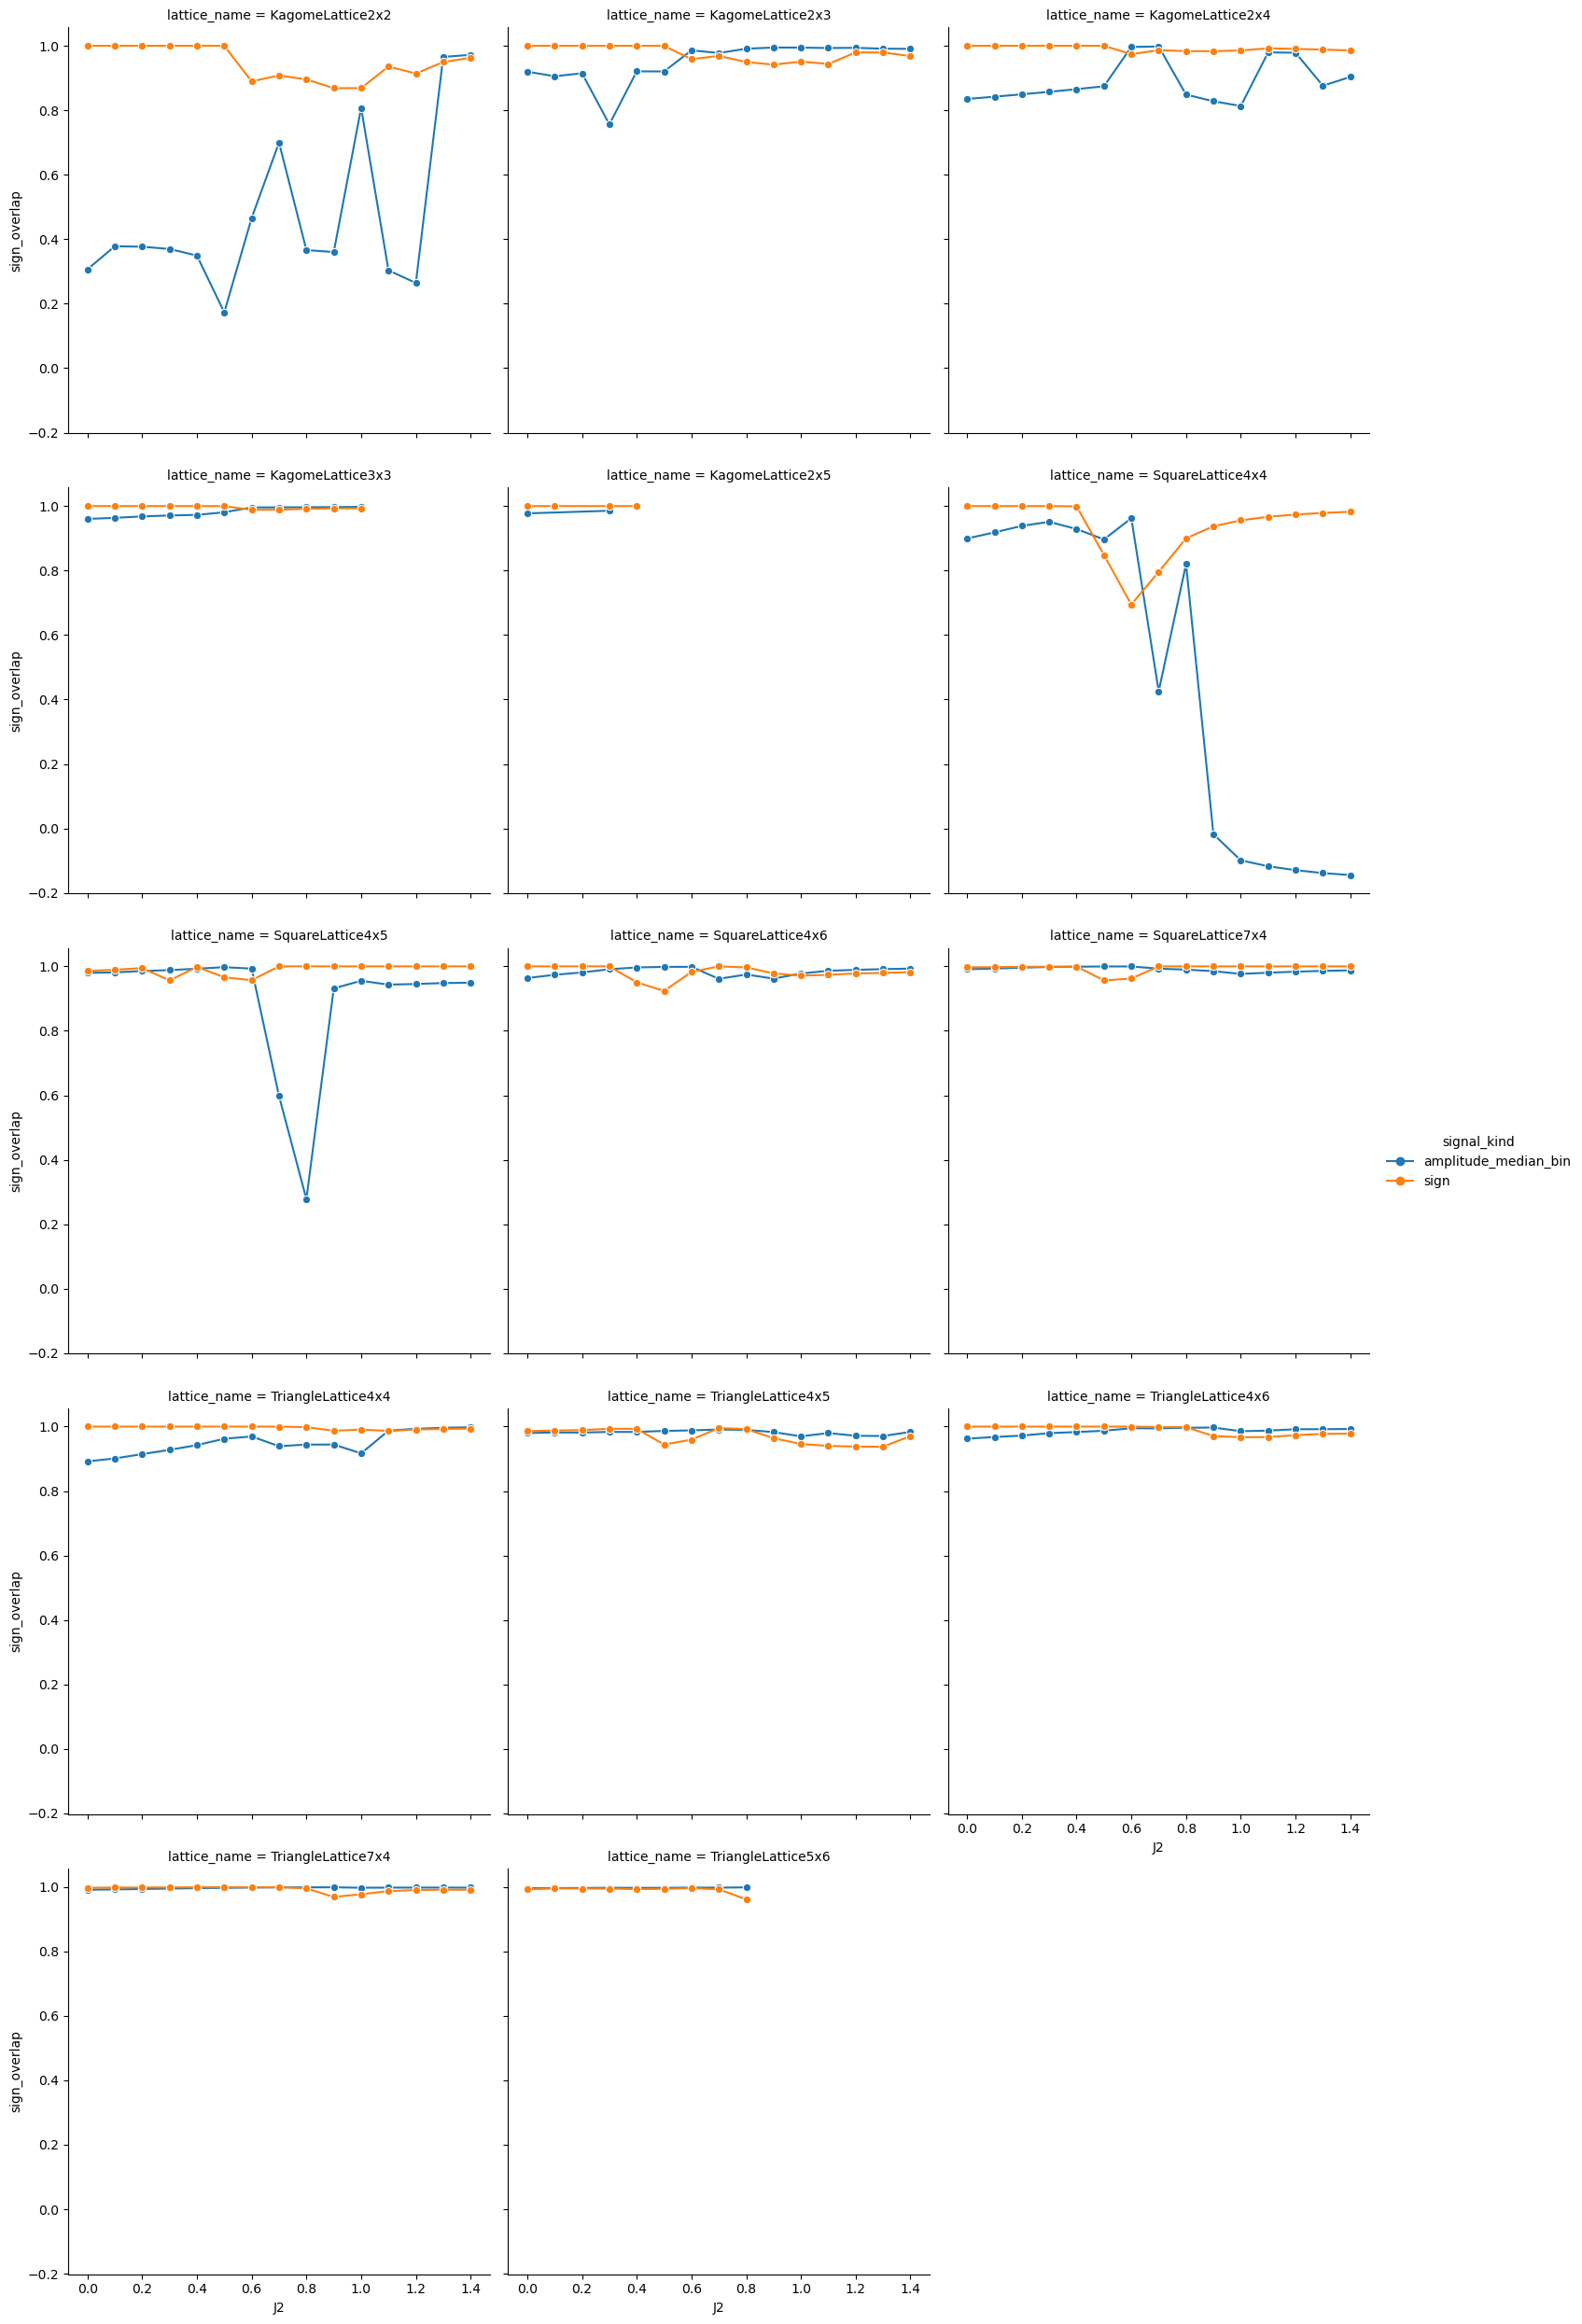

In [36]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="sign_overlap",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [54]:
complexity_ratio_df = (
    series_df.unstack(level="signal_kind")["total_hamming_weight"]
    .assign(
        ratio=lambda df: df["sign"] / df["amplitude_median_bin"],
        number_spins=lambda df: df.index.map(
            lambda name: name_to_lat_and_sym[name[0]][0].number_spins
        ),
        lattice_type=lambda df: df.index.map(
            lambda name: re.sub(r"\d.+", "", name_to_lat_and_sym[name[0]][0].get_cache_id())
        ),
    )
    .reset_index()
)


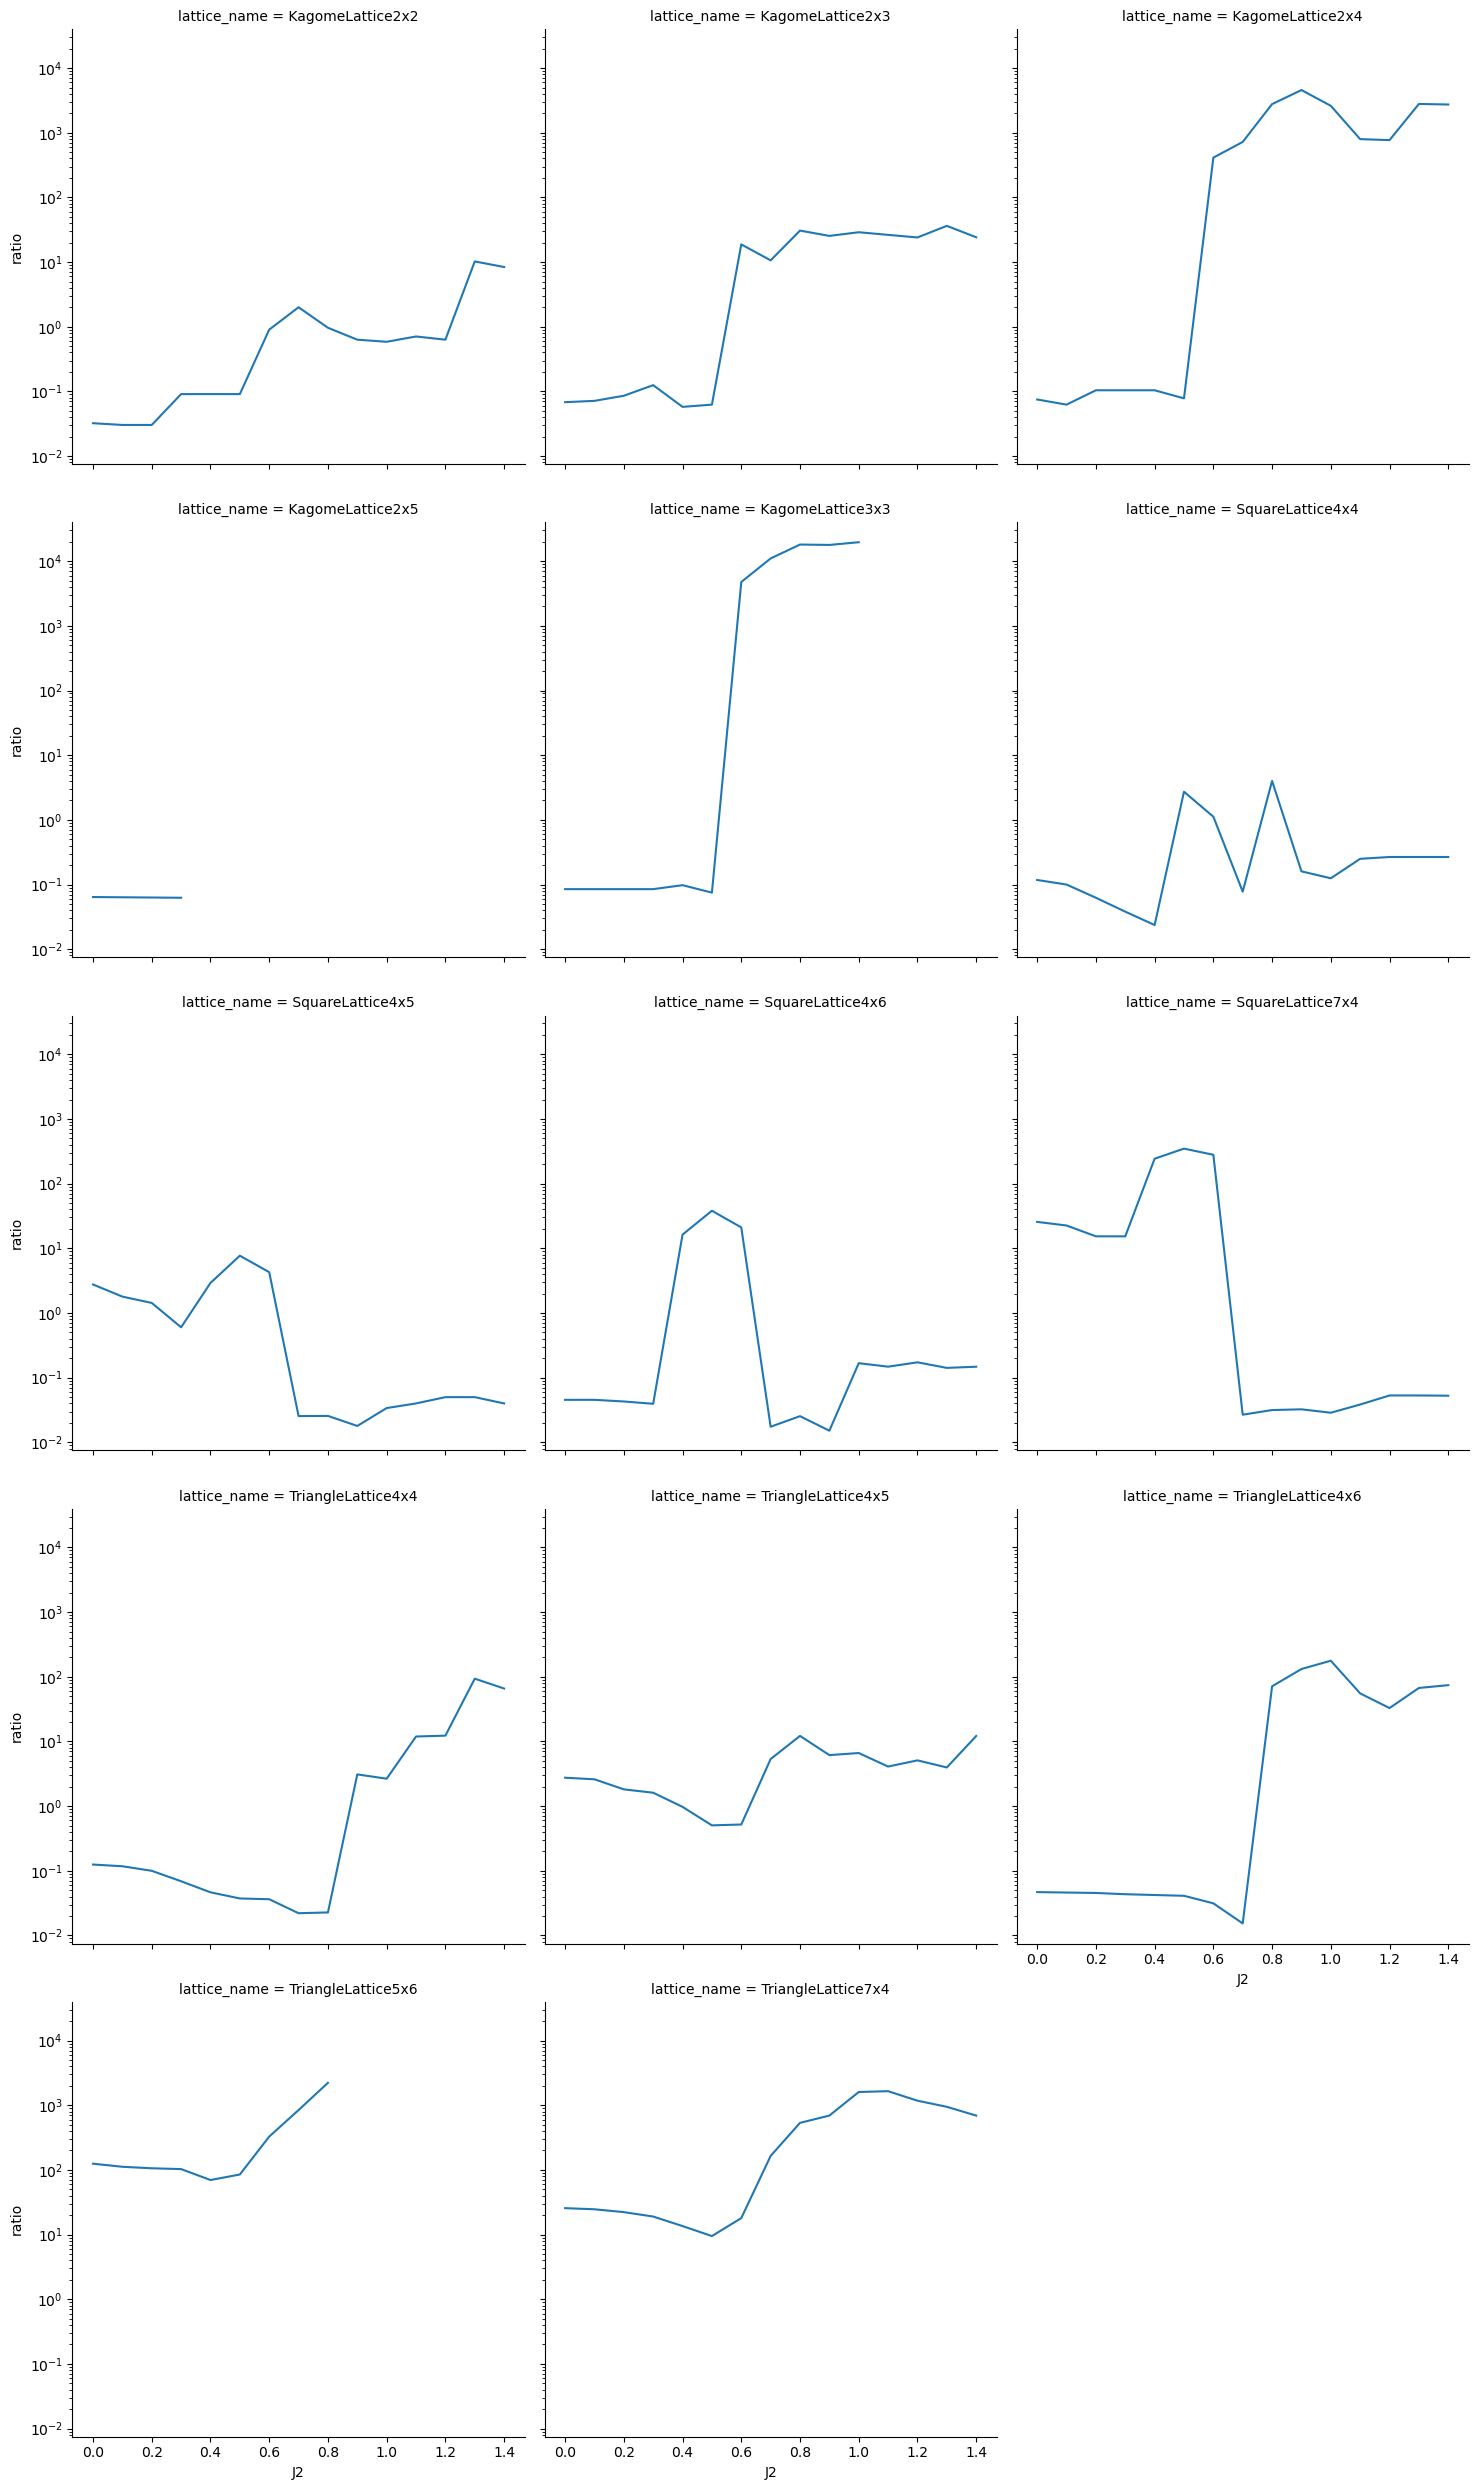

In [39]:
sns.relplot(
    complexity_ratio_df, x="J2", y="ratio", col="lattice_name", col_wrap=3, kind="line"
).set(yscale="log")


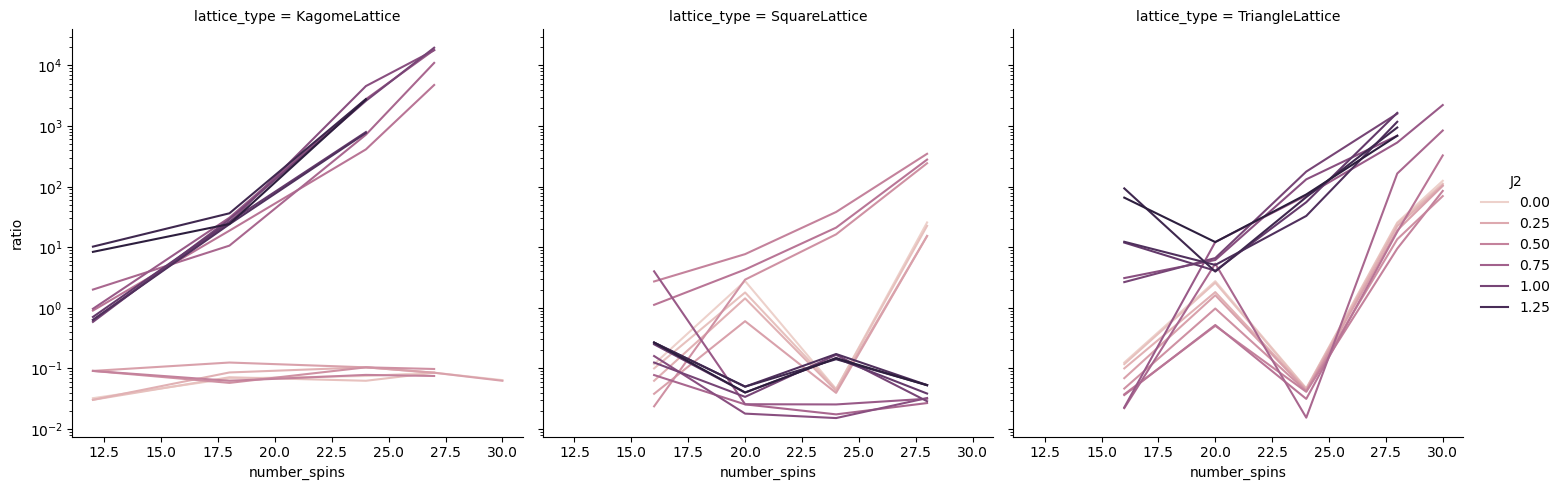

In [55]:
sns.relplot(
    complexity_ratio_df,
    x="number_spins",
    col="lattice_type",
    col_wrap=3,
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
